# INSURANCE FRAUD ML PIPELINE — ML Engineer Version

This notebook is rebuilt to be end-to-end interview and production aligned:
- dedicated EDA and data understanding
- leakage-safe temporal modeling
- robust preprocessing for skew/outliers
- correlation + signal diagnostics
- tuned models + CV variance
- SHAP explainability + model artifacts


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_validate
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV

from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestRegressor,
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer,
)

try:
    from scipy.stats import binomtest
except Exception:
    binomtest = None

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
except Exception:
    lgb = None
    LGBMClassifier = None

try:
    import shap
except Exception:
    shap = None

from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from scipy import sparse as sp
try:
    from catboost import CatBoostClassifier
except Exception:
    CatBoostClassifier = None

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
    from imblearn.combine import SMOTEENN
except Exception:
    ImbPipeline = None
    SMOTE = BorderlineSMOTE = ADASYN = SMOTEENN = None

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except Exception:
    variance_inflation_factor = None

try:
    import pandera as pa
except Exception:
    pa = None

try:
    import evidently
except Exception:
    evidently = None

try:
    import mlflow
except Exception:
    mlflow = None


try:
    import optuna
except Exception:
    optuna = None

import sys
ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "src").exists() and (ROOT_DIR.parent / "src").exists():
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

try:
    from src.models.anomaly_models import (
        IsolationForestAnomalyDetector,
        AutoencoderAnomalyDetector,
    )
except Exception:
    IsolationForestAnomalyDetector = None
    AutoencoderAnomalyDetector = None

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


In [3]:
# Load + merge + basic quality checks
data_dir = Path("data/raw")
if not data_dir.exists():
    data_dir = Path("../data/raw")

insurance = pd.read_csv(data_dir / "insurance_data.csv")
employee = pd.read_csv(data_dir / "employee_data.csv")
vendor = pd.read_csv(data_dir / "vendor_data.csv")

df = insurance.merge(employee, on="AGENT_ID", how="left", suffixes=("", "_AGENT"))
df = df.merge(vendor, on="VENDOR_ID", how="left", suffixes=("", "_VENDOR"))

print(f"Merged shape: {df.shape}")
print("\nClaim status counts:")
print(df["CLAIM_STATUS"].value_counts(dropna=False))

if "TRANSACTION_ID" in df.columns:
    dup_count = int(df.duplicated(subset=["TRANSACTION_ID"]).sum())
    print(f"\nDuplicate TRANSACTION_ID rows: {dup_count}")
    if dup_count > 0:
        df = df.drop_duplicates(subset=["TRANSACTION_ID"], keep="first").reset_index(drop=True)
        print(f"Shape after dedup: {df.shape}")


Merged shape: (10000, 53)

Claim status counts:
CLAIM_STATUS
A    9497
D     503
Name: count, dtype: int64

Duplicate TRANSACTION_ID rows: 0


In [4]:
# Fraud-only dataset with temporal ordering
df_cls = df[df["CLAIM_STATUS"].isin(["A", "D"])].copy()
df_cls["TXN_DATE_TIME"] = pd.to_datetime(df_cls["TXN_DATE_TIME"], errors="coerce")
df_cls = df_cls.sort_values("TXN_DATE_TIME").reset_index(drop=True)
df_cls["is_fraud"] = (df_cls["CLAIM_STATUS"] == "D").astype(int)

print(f"Classification rows: {len(df_cls):,}")
print(f"Fraud rate: {df_cls['is_fraud'].mean():.4f}")


Classification rows: 10,000
Fraud rate: 0.0503


## 1) EDA & Data Understanding


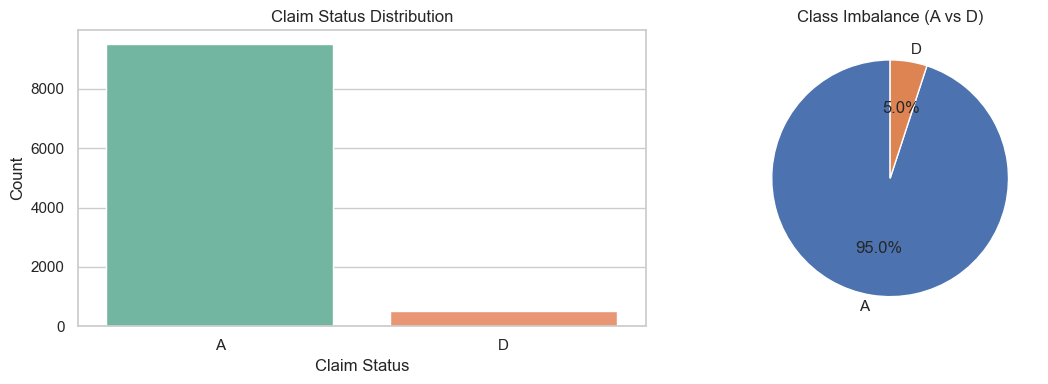

In [5]:
# Class imbalance chart
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
status_counts = df_cls["CLAIM_STATUS"].value_counts()

sns.barplot(x=status_counts.index, y=status_counts.values, ax=ax[0], palette="Set2")
ax[0].set_title("Claim Status Distribution")
ax[0].set_xlabel("Claim Status")
ax[0].set_ylabel("Count")

ax[1].pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%", startangle=90)
ax[1].set_title("Class Imbalance (A vs D)")

plt.tight_layout()
plt.show()


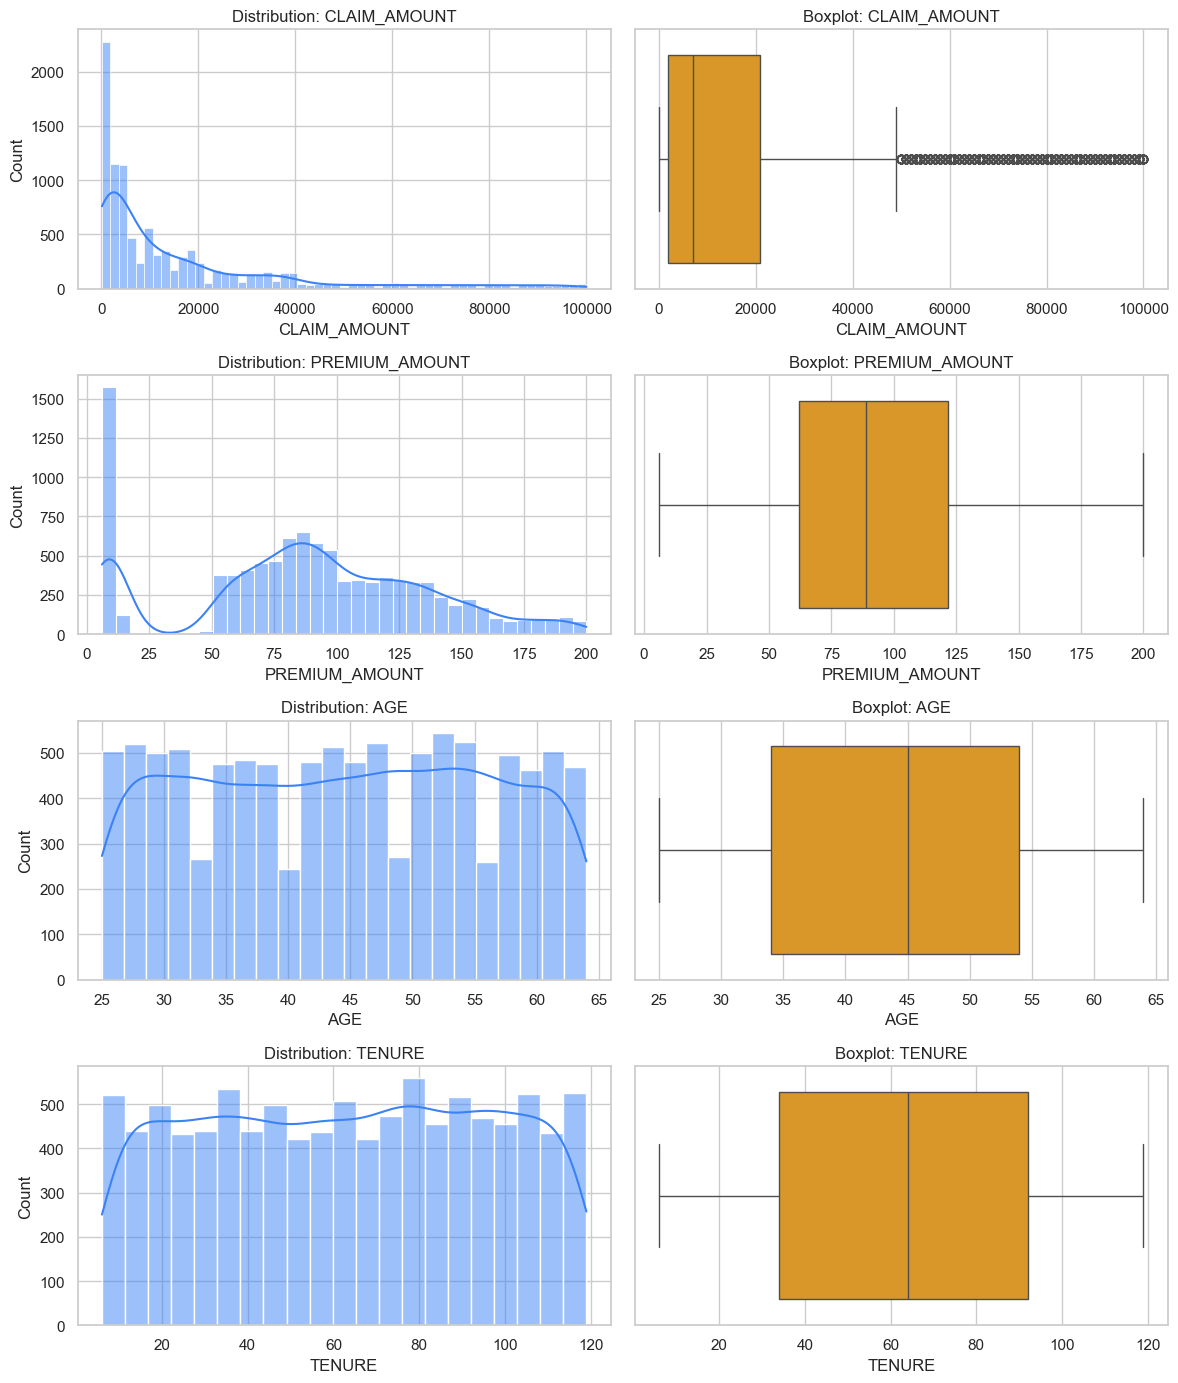

In [6]:
# Numeric distributions + outlier view
num_candidates = ["CLAIM_AMOUNT", "PREMIUM_AMOUNT", "AGE", "TENURE"]
num_cols = [c for c in num_candidates if c in df_cls.columns]

if num_cols:
    fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3.5 * len(num_cols)))
    if len(num_cols) == 1:
        axes = np.array([axes])
    for i, c in enumerate(num_cols):
        sns.histplot(df_cls[c], kde=True, ax=axes[i, 0], color="#3b82f6")
        axes[i, 0].set_title(f"Distribution: {c}")
        sns.boxplot(x=df_cls[c], ax=axes[i, 1], color="#f59e0b")
        axes[i, 1].set_title(f"Boxplot: {c}")
    plt.tight_layout()
    plt.show()


Top missing columns (%):


,missing_pct
ADDRESS_LINE2_VENDOR,88.55
ADDRESS_LINE2_AGENT,85.49
ADDRESS_LINE2,85.05
CITY_VENDOR,32.87
VENDOR_ID,32.45
ADDRESS_LINE1_VENDOR,32.45
VENDOR_NAME,32.45
POSTAL_CODE_VENDOR,32.45
STATE_VENDOR,32.45
AUTHORITY_CONTACTED,19.45


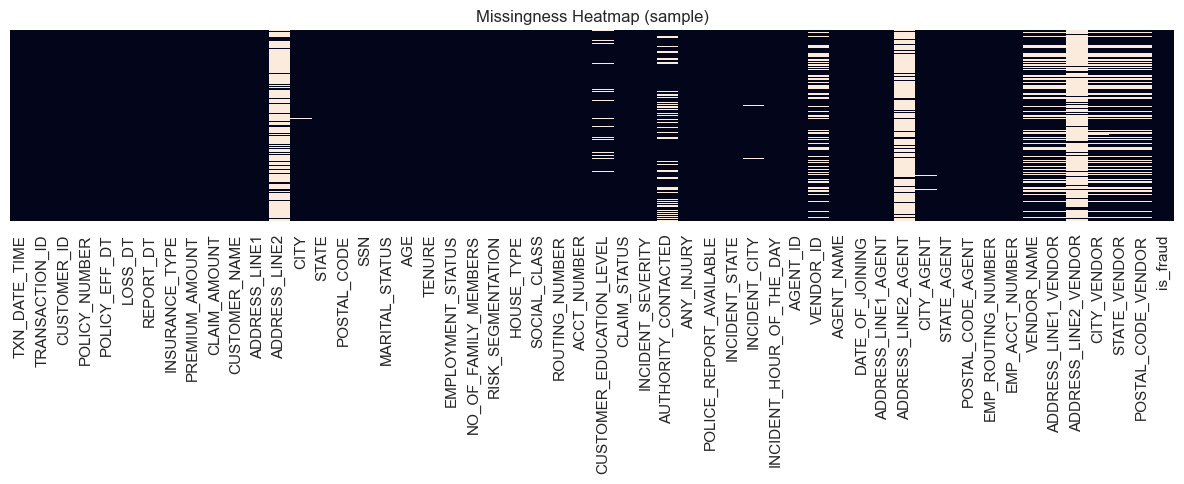

In [7]:
# Missing-value analysis
missing_df = (
    df_cls.isna().mean().mul(100).sort_values(ascending=False).rename("missing_pct").to_frame()
)
missing_df = missing_df[missing_df["missing_pct"] > 0]
print("Top missing columns (%):")
display(missing_df.head(20))

sample = df_cls.sample(min(500, len(df_cls)), random_state=42)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(sample.isna(), cbar=False, yticklabels=False, ax=ax)
ax.set_title("Missingness Heatmap (sample)")
plt.tight_layout()
plt.show()


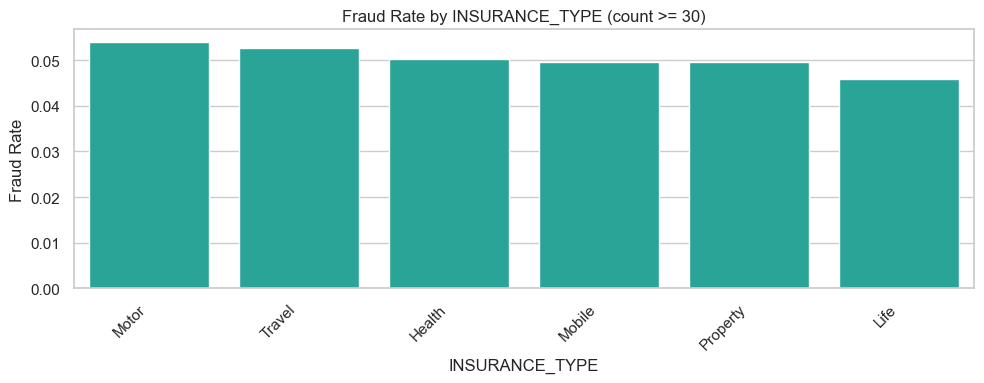

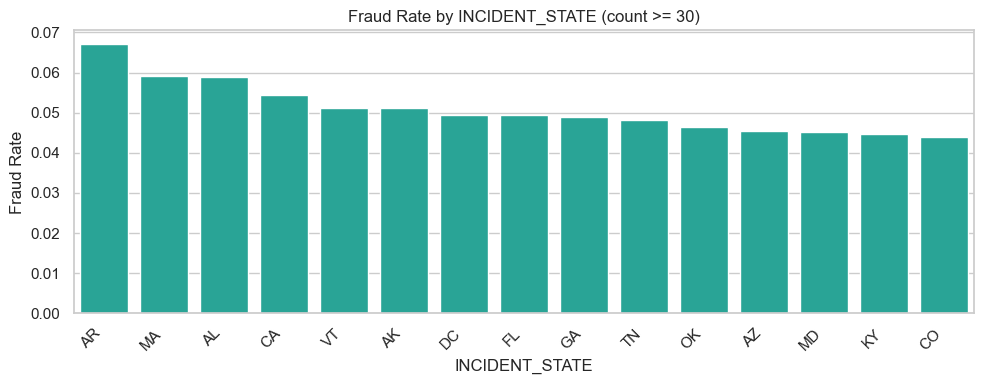

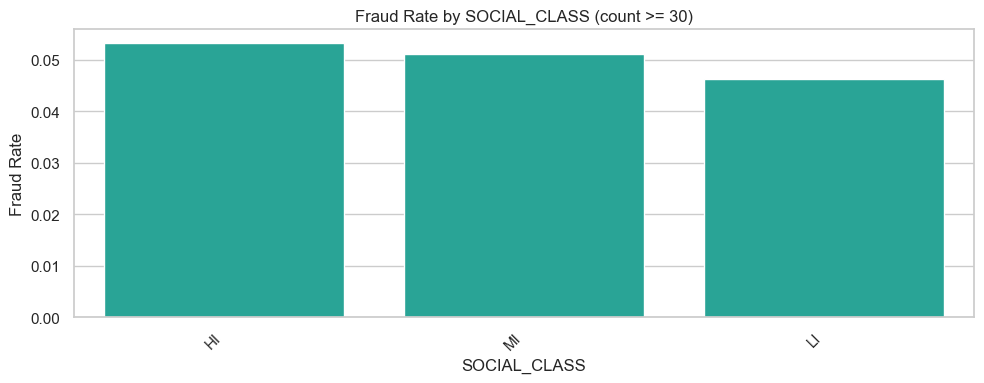

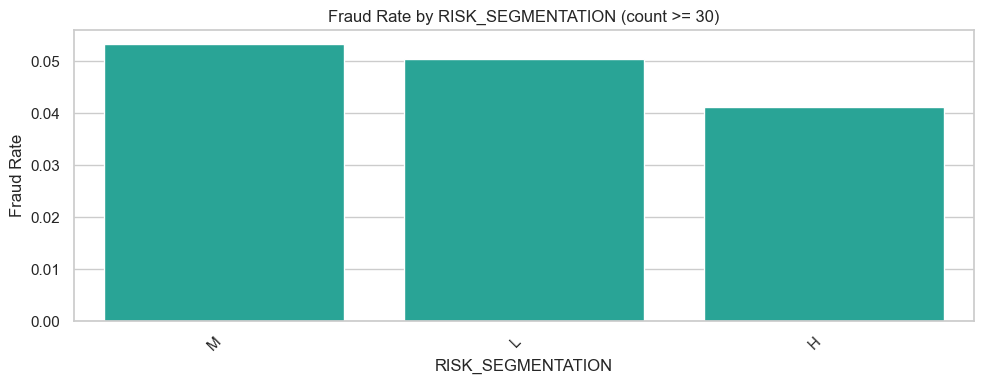

In [8]:
# Fraud rate by categorical feature (top categories)
cat_checks = ["INSURANCE_TYPE", "INCIDENT_STATE", "SOCIAL_CLASS", "RISK_SEGMENTATION"]
for col in cat_checks:
    if col not in df_cls.columns:
        continue
    grp = (
        df_cls.groupby(col)["is_fraud"]
        .agg(["mean", "count"])
        .query("count >= 30")
        .sort_values("mean", ascending=False)
        .head(15)
    )
    if grp.empty:
        continue

    plt.figure(figsize=(10, 4))
    sns.barplot(x=grp.index.astype(str), y=grp["mean"], color="#14b8a6")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Fraud Rate")
    plt.title(f"Fraud Rate by {col} (count >= 30)")
    plt.tight_layout()
    plt.show()


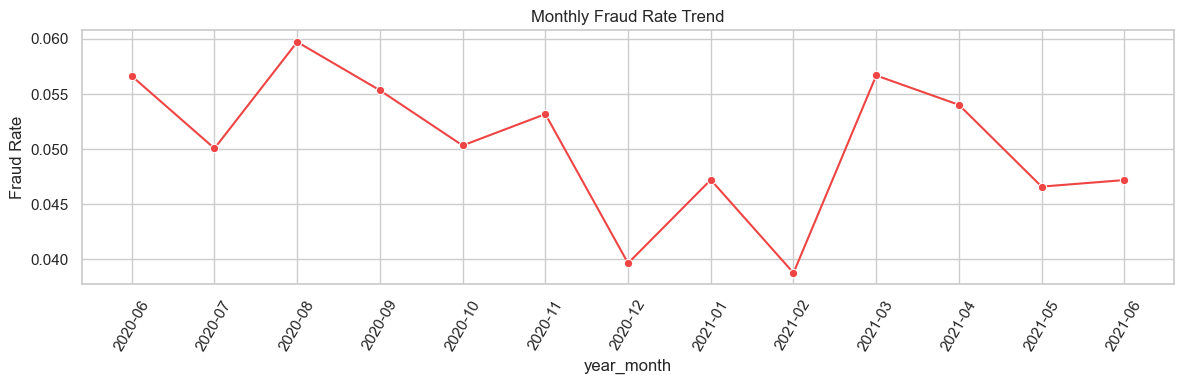

In [9]:
# Temporal fraud-rate trend
tmp = df_cls.copy()
tmp["year_month"] = tmp["TXN_DATE_TIME"].dt.to_period("M").astype(str)
monthly = tmp.groupby("year_month")["is_fraud"].mean().reset_index()

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly, x="year_month", y="is_fraud", marker="o", color="#ef4444")
plt.xticks(rotation=60)
plt.ylabel("Fraud Rate")
plt.title("Monthly Fraud Rate Trend")
plt.tight_layout()
plt.show()


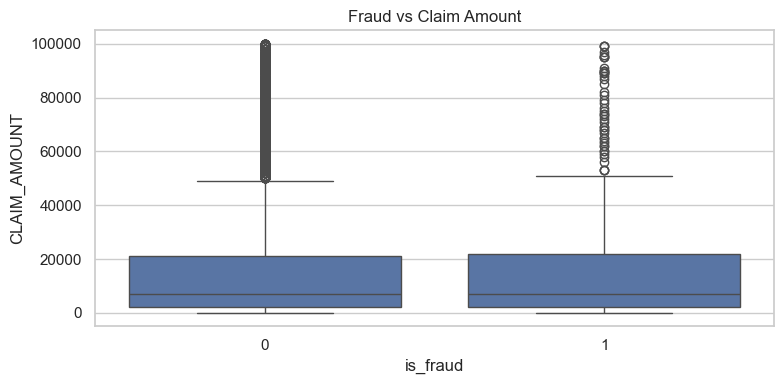

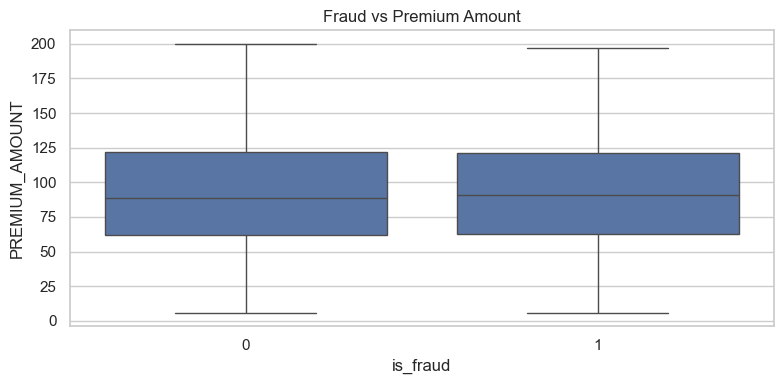

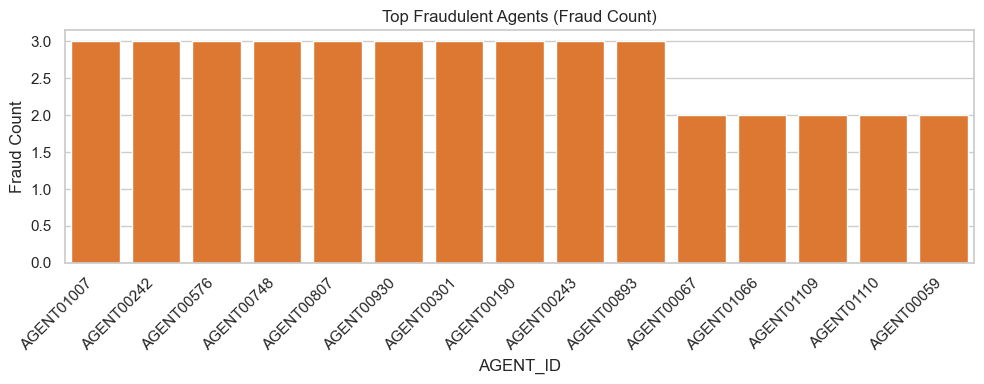

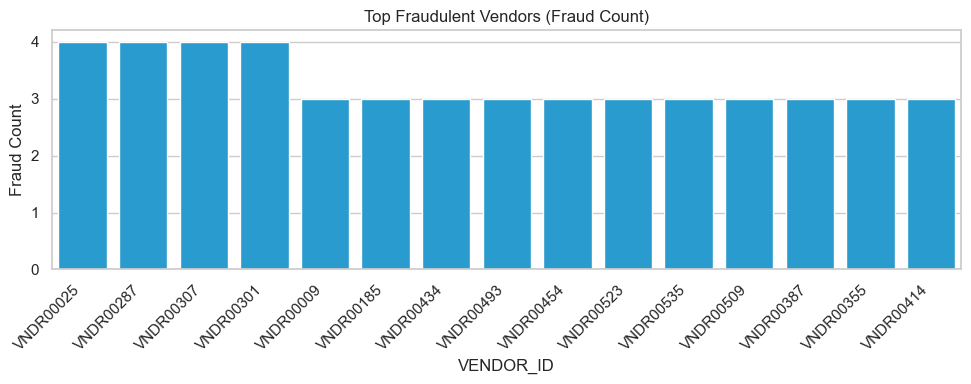

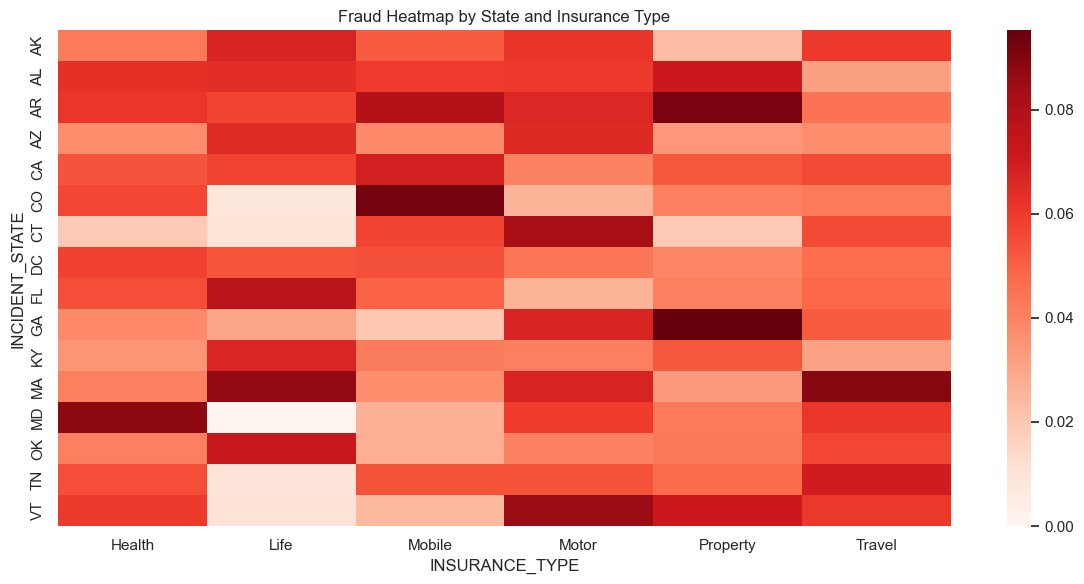

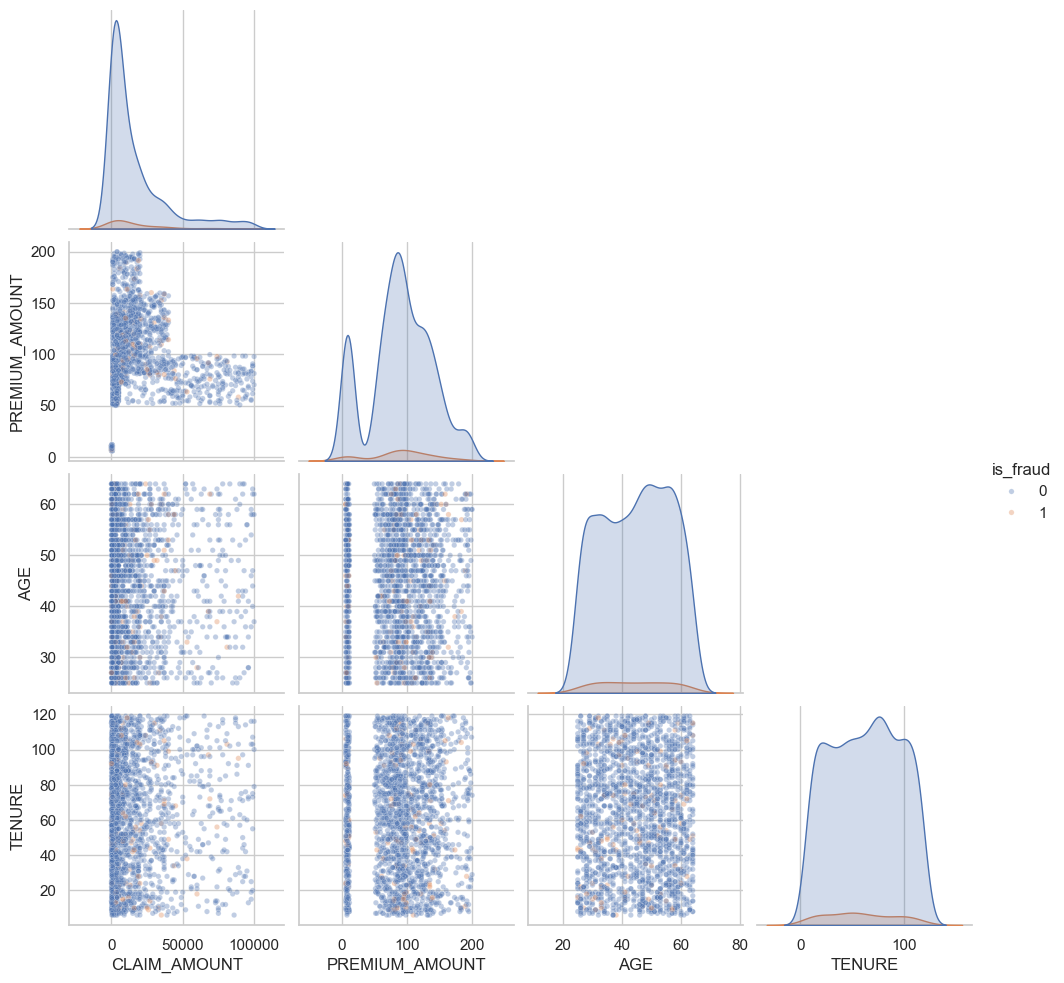

In [10]:
# Additional EDA requested: fraud vs amount/premium, top agents/vendors, state heatmap, pairplot
if "CLAIM_AMOUNT" in df_cls.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_cls, x="is_fraud", y="CLAIM_AMOUNT")
    plt.title("Fraud vs Claim Amount")
    plt.xlabel("is_fraud")
    plt.ylabel("CLAIM_AMOUNT")
    plt.tight_layout()
    plt.show()

if "PREMIUM_AMOUNT" in df_cls.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_cls, x="is_fraud", y="PREMIUM_AMOUNT")
    plt.title("Fraud vs Premium Amount")
    plt.xlabel("is_fraud")
    plt.ylabel("PREMIUM_AMOUNT")
    plt.tight_layout()
    plt.show()

if "AGENT_ID" in df_cls.columns:
    top_agents = (
        df_cls[df_cls["is_fraud"] == 1]
        .groupby("AGENT_ID")
        .size()
        .sort_values(ascending=False)
        .head(15)
    )
    if len(top_agents) > 0:
        plt.figure(figsize=(10, 4))
        sns.barplot(x=top_agents.index.astype(str), y=top_agents.values, color="#f97316")
        plt.xticks(rotation=45, ha="right")
        plt.title("Top Fraudulent Agents (Fraud Count)")
        plt.xlabel("AGENT_ID")
        plt.ylabel("Fraud Count")
        plt.tight_layout()
        plt.show()

if "VENDOR_ID" in df_cls.columns:
    top_vendors = (
        df_cls[df_cls["is_fraud"] == 1]
        .groupby("VENDOR_ID")
        .size()
        .sort_values(ascending=False)
        .head(15)
    )
    if len(top_vendors) > 0:
        plt.figure(figsize=(10, 4))
        sns.barplot(x=top_vendors.index.astype(str), y=top_vendors.values, color="#0ea5e9")
        plt.xticks(rotation=45, ha="right")
        plt.title("Top Fraudulent Vendors (Fraud Count)")
        plt.xlabel("VENDOR_ID")
        plt.ylabel("Fraud Count")
        plt.tight_layout()
        plt.show()

if all(c in df_cls.columns for c in ["INCIDENT_STATE", "INSURANCE_TYPE"]):
    state_heat = (
        df_cls.groupby(["INCIDENT_STATE", "INSURANCE_TYPE"])["is_fraud"]
        .mean()
        .unstack(fill_value=0)
    )
    if state_heat.shape[0] > 1 and state_heat.shape[1] > 1:
        plt.figure(figsize=(12, 6))
        sns.heatmap(state_heat, cmap="Reds", annot=False)
        plt.title("Fraud Heatmap by State and Insurance Type")
        plt.xlabel("INSURANCE_TYPE")
        plt.ylabel("INCIDENT_STATE")
        plt.tight_layout()
        plt.show()

pair_candidates = [c for c in ["CLAIM_AMOUNT", "PREMIUM_AMOUNT", "AGE", "TENURE", "claim_to_premium_ratio"] if c in df_cls.columns]
if len(pair_candidates) >= 2:
    pair_df = df_cls[pair_candidates + ["is_fraud"]].copy()
    pair_df = pair_df.dropna().sample(min(2000, len(pair_df.dropna())), random_state=42)
    sns.pairplot(pair_df, vars=pair_candidates[:4], hue="is_fraud", corner=True, diag_kind="kde", plot_kws={"alpha": 0.35, "s": 15})
    plt.show()


## 2) Temporal Split + Leakage-Safe Feature Engineering


In [11]:
# Temporal split + fraud-rate drift checks
n = len(df_cls)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_cls.iloc[:train_end].copy()
val_df = df_cls.iloc[train_end:val_end].copy()
test_df = df_cls.iloc[val_end:].copy()

tr_rate, va_rate, te_rate = train_df["is_fraud"].mean(), val_df["is_fraud"].mean(), test_df["is_fraud"].mean()
print(f"Rows -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
print(f"Fraud rate -> train: {tr_rate:.4f}, val: {va_rate:.4f}, test: {te_rate:.4f}")

for name, drift in {
    "train vs val": abs(tr_rate - va_rate),
    "train vs test": abs(tr_rate - te_rate),
}.items():
    try:
        assert drift < 0.02
        print(f"Drift check OK ({name}): {drift:.4f}")
    except AssertionError:
        print(f"Warning: fraud-rate drift high ({name}): {drift:.4f}")


Rows -> train: 7000, val: 1500, test: 1500
Fraud rate -> train: 0.0499, val: 0.0567, test: 0.0460
Drift check OK (train vs val): 0.0068
Drift check OK (train vs test): 0.0039


In [12]:
# Helper functions: domain features, temporal behavioral signals, cardinality, outlier caps
def add_domain_features(df_in):
    d = df_in.copy()
    for c in ["LOSS_DT", "REPORT_DT", "TXN_DATE_TIME", "POLICY_EFF_DT", "DATE_OF_JOINING"]:
        if c in d.columns:
            d[c] = pd.to_datetime(d[c], errors="coerce")

    if "CUSTOMER_ID" in d.columns and "TXN_DATE_TIME" in d.columns:
        d = d.sort_values("TXN_DATE_TIME")
        d["customer_claim_count"] = d.groupby("CUSTOMER_ID").cumcount()
    else:
        d["customer_claim_count"] = 0

    if {"LOSS_DT", "REPORT_DT"}.issubset(d.columns):
        d["days_to_report"] = (d["REPORT_DT"] - d["LOSS_DT"]).dt.days
    else:
        d["days_to_report"] = np.nan

    d["late_report_flag"] = (d["days_to_report"] > 30).astype(float)

    if {"CLAIM_AMOUNT", "PREMIUM_AMOUNT"}.issubset(d.columns):
        denom = d["PREMIUM_AMOUNT"].replace(0, np.nan)
        d["claim_to_premium_ratio"] = d["CLAIM_AMOUNT"] / denom
    else:
        d["claim_to_premium_ratio"] = np.nan

    if {"TXN_DATE_TIME", "POLICY_EFF_DT"}.issubset(d.columns):
        d["policy_age_years"] = (d["TXN_DATE_TIME"] - d["POLICY_EFF_DT"]).dt.days / 365.25
    else:
        d["policy_age_years"] = np.nan

    if {"TXN_DATE_TIME", "DATE_OF_JOINING"}.issubset(d.columns):
        d["agent_experience_years"] = (d["TXN_DATE_TIME"] - d["DATE_OF_JOINING"]).dt.days / 365.25
    else:
        d["agent_experience_years"] = np.nan

    d["VENDOR_ID_MISSING"] = d["VENDOR_ID"].isna().astype(int) if "VENDOR_ID" in d.columns else 0
    d["AUTHORITY_CONTACTED_MISSING"] = d["AUTHORITY_CONTACTED"].isna().astype(int) if "AUTHORITY_CONTACTED" in d.columns else 0
    return d


def add_temporal_entity_features(history_df, apply_df, entity_col, prefix, windows=(7, 30), target_col="is_fraud"):
    out = apply_df.copy()
    for w in windows:
        out[f"{prefix}_{w}d_claim_count"] = 0
    out[f"{prefix}_days_since_last_claim"] = np.nan

    global_rate = float(history_df[target_col].mean()) if target_col in history_df.columns else 0.0
    if np.isnan(global_rate):
        global_rate = 0.0
    out[f"{prefix}_rolling_fraud_rate"] = global_rate

    req_cols = {entity_col, "TXN_DATE_TIME"}
    if not req_cols.issubset(history_df.columns) or not req_cols.issubset(apply_df.columns):
        if 30 in windows:
            out[f"{prefix}_claim_velocity"] = out[f"{prefix}_30d_claim_count"] / 30.0
        return out

    hist = history_df[[entity_col, "TXN_DATE_TIME", target_col]].copy()
    hist = hist.dropna(subset=["TXN_DATE_TIME"])
    app = apply_df[[entity_col, "TXN_DATE_TIME"]].copy()
    app = app.dropna(subset=["TXN_DATE_TIME"])
    app["__row_id__"] = np.arange(len(app), dtype=int)
    app[target_col] = np.nan

    hist["__row_id__"] = -1
    tmp = pd.concat([hist, app], ignore_index=True, sort=False)
    tmp = tmp.sort_values([entity_col, "TXN_DATE_TIME", "__row_id__"]).reset_index(drop=True)

    for w in windows:
        tmp[f"{prefix}_{w}d_claim_count"] = 0
    tmp[f"{prefix}_days_since_last_claim"] = np.nan
    tmp[f"{prefix}_rolling_fraud_rate"] = global_rate

    day_ns = float(pd.Timedelta(days=1).value)

    for _, g in tmp.groupby(entity_col, sort=False):
        idx = g.index.to_numpy()
        t_ns = pd.to_datetime(g["TXN_DATE_TIME"], errors="coerce").astype("int64").to_numpy()
        y_vals = pd.to_numeric(g[target_col], errors="coerce").to_numpy()

        if len(idx) > 1:
            gaps = np.full(len(idx), np.nan, dtype=float)
            gaps[1:] = (t_ns[1:] - t_ns[:-1]) / day_ns
            tmp.loc[idx, f"{prefix}_days_since_last_claim"] = gaps

        for w in windows:
            win_ns = pd.Timedelta(days=w).value
            counts = np.zeros(len(idx), dtype=int)
            left = 0
            for i in range(len(idx)):
                while left < i and t_ns[left] < (t_ns[i] - win_ns):
                    left += 1
                counts[i] = i - left
            tmp.loc[idx, f"{prefix}_{w}d_claim_count"] = counts

        prior_sum = 0.0
        prior_n = 0
        rates = np.full(len(idx), global_rate, dtype=float)
        for i in range(len(idx)):
            rates[i] = (prior_sum / prior_n) if prior_n > 0 else global_rate
            yi = y_vals[i]
            if not np.isnan(yi):
                prior_sum += yi
                prior_n += 1
        tmp.loc[idx, f"{prefix}_rolling_fraud_rate"] = rates

    feat_cols = [f"{prefix}_{w}d_claim_count" for w in windows] + [f"{prefix}_days_since_last_claim", f"{prefix}_rolling_fraud_rate"]
    apply_feats = tmp[tmp["__row_id__"] >= 0].sort_values("__row_id__").set_index("__row_id__")[feat_cols]

    aligned = pd.DataFrame(index=np.arange(len(apply_df)))
    for c in feat_cols:
        aligned[c] = np.nan
    aligned.loc[apply_feats.index, feat_cols] = apply_feats.values

    for c in feat_cols:
        out[c] = aligned[c].values

    if 30 in windows:
        out[f"{prefix}_claim_velocity"] = out[f"{prefix}_30d_claim_count"] / 30.0
    return out


def fit_rate_map(train_part, key, target="is_fraud", k=10):
    g = train_part.groupby(key)[target].agg(["sum", "count"]).rename(columns={"sum": "s", "count": "n"})
    global_rate = train_part[target].mean()
    g["rate"] = (g["s"] + k * global_rate) / (g["n"] + k)
    return g[["s", "n", "rate"]], float(global_rate)


def apply_rate_map(df_apply, key, rate_tbl, global_rate, out_col):
    out = df_apply.copy()
    out[out_col] = out[key].map(rate_tbl["rate"]).fillna(global_rate)
    return out


def add_leave_one_out_rate(train_part, key, target="is_fraud", k=10, out_col="rate"):
    out = train_part.copy()
    global_rate = out[target].mean()
    g = out.groupby(key)[target].agg(["sum", "count"]).rename(columns={"sum": "s", "count": "n"})
    s = out[key].map(g["s"])
    n = out[key].map(g["n"])
    y = out[target]
    numer = (s - y) + k * global_rate
    denom = (n - 1) + k
    out[out_col] = np.where((n - 1) > 0, numer / denom, global_rate)
    out[out_col] = out[out_col].fillna(global_rate)
    return out


def cap_high_cardinality(train_x, val_x, test_x, max_unique=50):
    tr, va, te = train_x.copy(), val_x.copy(), test_x.copy()
    cap_info = {}
    cat_cols = list(tr.select_dtypes(include=["object", "category", "string"]).columns)
    for col in cat_cols:
        nunq = tr[col].nunique(dropna=True)
        if nunq <= max_unique:
            continue
        top_vals = tr[col].value_counts(dropna=True).head(max_unique).index
        cap_info[col] = list(top_vals)
        tr[col] = np.where(tr[col].isin(top_vals), tr[col], "__OTHER__")
        va[col] = np.where(va[col].isin(top_vals), va[col], "__OTHER__")
        te[col] = np.where(te[col].isin(top_vals), te[col], "__OTHER__")
    return tr, va, te, cap_info


def fit_iqr_caps(train_x, numeric_cols, mult=3.0):
    bounds = {}
    for c in numeric_cols:
        s = pd.to_numeric(train_x[c], errors="coerce")
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - mult * iqr
        hi = q3 + mult * iqr
        bounds[c] = (lo, hi)
    return bounds


def apply_iqr_caps(df_x, bounds):
    out = df_x.copy()
    for c, (lo, hi) in bounds.items():
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce").clip(lo, hi)
    return out


def normalize_datetime_cols(df_x):
    out = df_x.copy()
    dt_cols = out.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns
    for c in dt_cols:
        s = pd.to_datetime(out[c], errors="coerce").astype("int64")
        out[c] = s.replace(-9223372036854775808, np.nan).astype(float)
    return out


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def build_preprocessor(X):
    cat_cols = list(X.select_dtypes(include=["object", "category", "string"]).columns)
    num_cols = [c for c in X.columns if c not in cat_cols]
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
    cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", make_ohe())])
    return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])


In [13]:
# Apply leakage-safe features
train_fe = add_domain_features(train_df)
val_fe = add_domain_features(val_df)
test_fe = add_domain_features(test_df)

if "CUSTOMER_ID" in train_fe.columns:
    train_fe = add_temporal_entity_features(train_fe, train_fe, "CUSTOMER_ID", "customer", windows=(7, 30))
    val_fe = add_temporal_entity_features(train_fe, val_fe, "CUSTOMER_ID", "customer", windows=(7, 30))
    test_fe = add_temporal_entity_features(train_fe, test_fe, "CUSTOMER_ID", "customer", windows=(7, 30))

for entity_col, prefix in [("AGENT_ID", "agent"), ("VENDOR_ID", "vendor")]:
    if entity_col in train_fe.columns:
        train_fe = add_temporal_entity_features(train_fe, train_fe, entity_col, prefix, windows=(30,))
        val_fe = add_temporal_entity_features(train_fe, val_fe, entity_col, prefix, windows=(30,))
        test_fe = add_temporal_entity_features(train_fe, test_fe, entity_col, prefix, windows=(30,))

for dfx in [train_fe, val_fe, test_fe]:
    if "customer_days_since_last_claim" in dfx.columns:
        dfx["days_since_last_claim"] = dfx["customer_days_since_last_claim"]
    if "customer_30d_claim_count" in dfx.columns:
        dfx["claim_velocity"] = dfx["customer_30d_claim_count"] / 30.0
    if "customer_rolling_fraud_rate" in dfx.columns:
        dfx["rolling_fraud_rate"] = dfx["customer_rolling_fraud_rate"]

for key, out_col in [("AGENT_ID", "agent_fraud_rate"), ("VENDOR_ID", "vendor_fraud_rate"), ("INCIDENT_STATE", "state_fraud_rate")]:
    if key not in train_fe.columns:
        continue
    train_fe = add_leave_one_out_rate(train_fe, key=key, target="is_fraud", k=10, out_col=out_col)
    rate_tbl, global_rate = fit_rate_map(train_fe, key=key, target="is_fraud", k=10)
    val_fe = apply_rate_map(val_fe, key, rate_tbl, global_rate, out_col)
    test_fe = apply_rate_map(test_fe, key, rate_tbl, global_rate, out_col)

if "AGENT_ID" in train_fe.columns:
    vol_map = train_fe.groupby("AGENT_ID")["is_fraud"].size()
    train_fe["agent_claim_volume"] = train_fe["AGENT_ID"].map(vol_map).fillna(0)
    val_fe["agent_claim_volume"] = val_fe["AGENT_ID"].map(vol_map).fillna(0)
    test_fe["agent_claim_volume"] = test_fe["AGENT_ID"].map(vol_map).fillna(0)
else:
    train_fe["agent_claim_volume"] = 0
    val_fe["agent_claim_volume"] = 0
    test_fe["agent_claim_volume"] = 0

print("Feature engineering complete.")
new_feats = [
    "customer_7d_claim_count", "customer_30d_claim_count",
    "agent_30d_claim_count", "vendor_30d_claim_count",
    "days_since_last_claim", "rolling_fraud_rate", "claim_velocity"
]
print("Requested temporal fraud features present:")
print({f: (f in train_fe.columns) for f in new_feats})


Feature engineering complete.
Requested temporal fraud features present:
{'customer_7d_claim_count': True, 'customer_30d_claim_count': True, 'agent_30d_claim_count': True, 'vendor_30d_claim_count': True, 'days_since_last_claim': True, 'rolling_fraud_rate': True, 'claim_velocity': True}


In [14]:
# Feature matrix prep: drop leakage/PII + cardinality cap + outlier capping
drop_cols = [
    "CLAIM_STATUS", "is_fraud", "TXN_DATE_TIME",
    "CUSTOMER_NAME", "SSN", "ACCT_NUMBER", "ROUTING_NUMBER",
    "EMP_ACCT_NUMBER", "EMP_ROUTING_NUMBER", "ADDRESS_LINE1",
    "TRANSACTION_ID", "POLICY_NUMBER",
]

X_train_raw = train_fe.drop(columns=[c for c in drop_cols if c in train_fe.columns], errors="ignore")
y_train = train_fe["is_fraud"].copy()
X_val_raw = val_fe.drop(columns=[c for c in drop_cols if c in val_fe.columns], errors="ignore")
y_val = val_fe["is_fraud"].copy()
X_test_raw = test_fe.drop(columns=[c for c in drop_cols if c in test_fe.columns], errors="ignore")
y_test = test_fe["is_fraud"].copy()

X_train_card, X_val_card, X_test_card, cardinality_map = cap_high_cardinality(
    X_train_raw, X_val_raw, X_test_raw, max_unique=50
)

num_cols = list(X_train_card.select_dtypes(include=[np.number]).columns)
outlier_bounds = fit_iqr_caps(X_train_card, num_cols, mult=3.0)

X_train = apply_iqr_caps(X_train_card, outlier_bounds)
X_val = apply_iqr_caps(X_val_card, outlier_bounds)
X_test = apply_iqr_caps(X_test_card, outlier_bounds)

# Convert datetime columns to numeric timestamps for sklearn compatibility
X_train = normalize_datetime_cols(X_train)
X_val = normalize_datetime_cols(X_val)
X_test = normalize_datetime_cols(X_test)

print(f"Train features: {X_train.shape}")
print(f"Val features  : {X_val.shape}")
print(f"Test features : {X_test.shape}")
print(f"High-cardinality capped columns: {len(cardinality_map)}")


Train features: (7000, 70)
Val features  : (1500, 70)
Test features : (1500, 70)
High-cardinality capped columns: 13


## 3) Correlation & Signal Analysis


Top positive correlations with is_fraud:


,Correlation
customer_rolling_fraud_rate,1.000000
rolling_fraud_rate,1.000000
agent_rolling_fraud_rate,0.637745
vendor_rolling_fraud_rate,0.412782
ROUTING_NUMBER,0.018870
VENDOR_ID_MISSING,0.018486
POSTAL_CODE_VENDOR,0.008074
PREMIUM_AMOUNT,0.007908
vendor_fraud_rate,0.006787
POLICE_REPORT_AVAILABLE,0.005456


Top negative correlations with is_fraud:


,Correlation
agent_30d_claim_count,-0.023502
agent_claim_velocity,-0.023502
days_to_report,-0.023916
ANY_INJURY,-0.025782
state_fraud_rate,-0.077313
customer_claim_count,NaN
late_report_flag,NaN
customer_7d_claim_count,NaN
customer_30d_claim_count,NaN
customer_days_since_last_claim,NaN


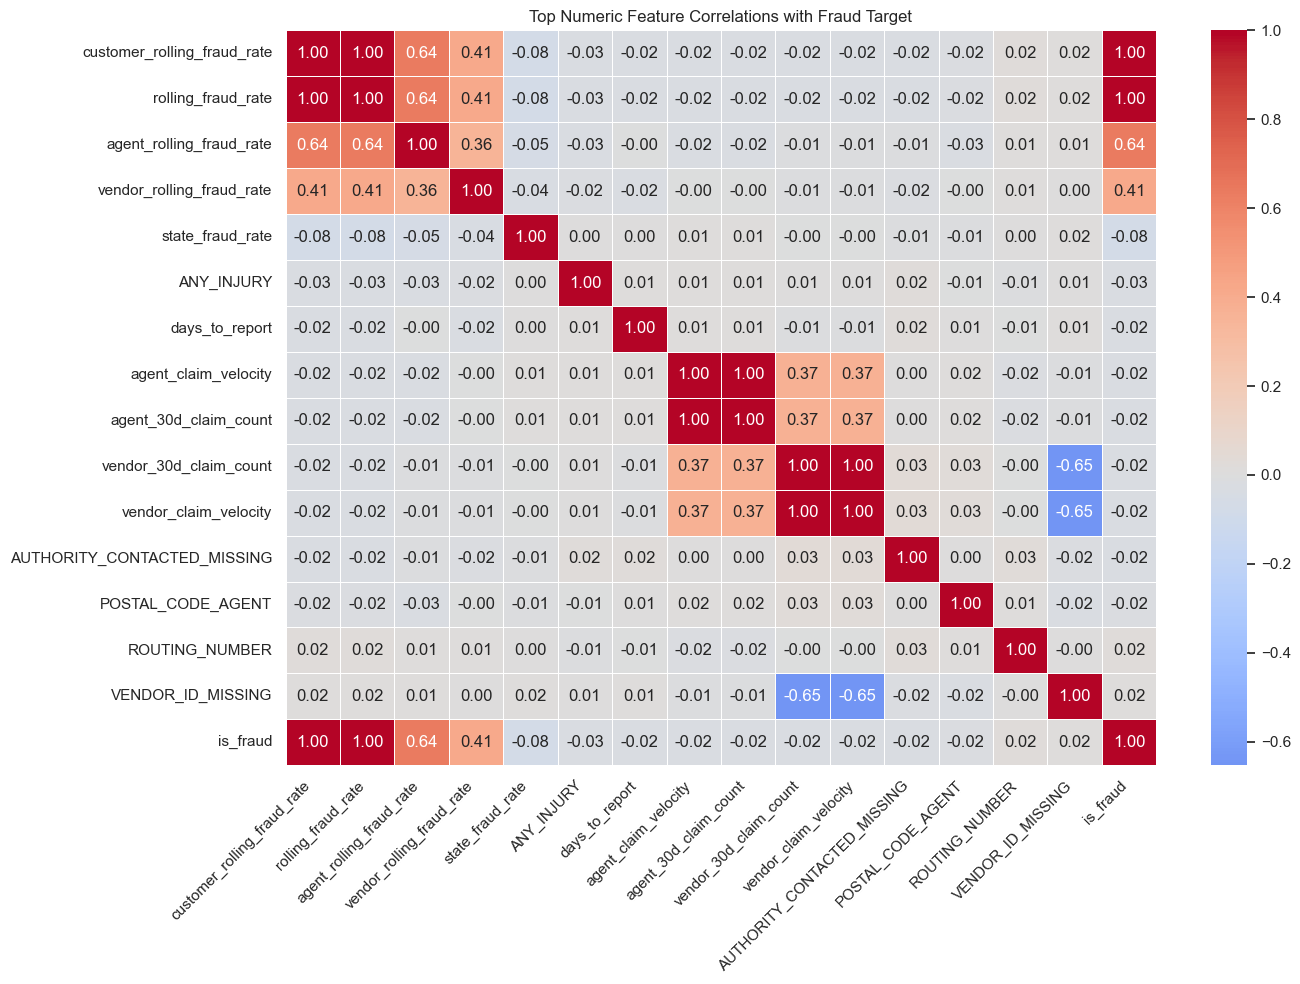

In [15]:
# Numeric correlation with fraud target
corr_df = train_fe.select_dtypes(include=[np.number]).copy()

if "is_fraud" not in corr_df.columns:
    corr_df["is_fraud"] = train_fe["is_fraud"]

corr_series = (
    corr_df.corr(numeric_only=True)["is_fraud"]
    .drop("is_fraud", errors="ignore")
    .sort_values(ascending=False)
)

print("Top positive correlations with is_fraud:")
display(corr_series.head(15).to_frame("Correlation"))

print("Top negative correlations with is_fraud:")
display(corr_series.tail(15).to_frame("Correlation"))

# Top correlated features
heat_cols = (
    corr_series.abs()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

heat_cols.append("is_fraud")

corr_matrix = train_fe[heat_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,          # show values
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=False
)

plt.title("Top Numeric Feature Correlations with Fraud Target")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [16]:
# Cramer's V for categorical signal + mutual information
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.sum().sum()
    r, k = table.shape
    denom = max(1e-9, n * min(k - 1, r - 1))
    return np.sqrt(chi2 / denom)

cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
cv_rows = []
for c in cat_cols:
    nunq = X_train[c].nunique(dropna=True)
    if nunq < 2 or nunq > 100:
        continue
    v = cramers_v(X_train[c].fillna("__NA__"), y_train)
    cv_rows.append((c, v))

cv_df = pd.DataFrame(cv_rows, columns=["feature", "cramers_v"]).sort_values("cramers_v", ascending=False)
print("Top categorical signal (Cramer's V):")
display(cv_df.head(15))

# mutual_info_classif needs non-datetime numeric matrix
mi_base = X_train.copy()
dt_cols = mi_base.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns
for c in dt_cols:
    s = pd.to_datetime(mi_base[c], errors="coerce").astype("int64")
    mi_base[c] = s.replace(-9223372036854775808, np.nan)

mi_df = pd.get_dummies(mi_base.fillna("__NA__"), drop_first=False)
mi_df = mi_df.replace({True: 1, False: 0}).astype(float)

mi = mutual_info_classif(mi_df, y_train, random_state=42)
mi_out = pd.DataFrame({"feature": mi_df.columns, "mutual_info": mi}).sort_values("mutual_info", ascending=False)
print("Top mutual information features:")
display(mi_out.head(20))


Top categorical signal (Cramer's V):


,feature,cramers_v


Top mutual information features:


,feature,mutual_info
39,state_fraud_rate,0.187690
32,vendor_rolling_fraud_rate,0.047849
34,days_since_last_claim,0.009568
461,AGENT_NAME_Yolanda Samples,0.007935
925,POSTAL_CODE_VENDOR_32444.0,0.006839
69,CUSTOMER_ID_A00006283,0.006791
870,POSTAL_CODE_VENDOR_2540.0,0.006539
408,VENDOR_ID_VNDR00590,0.006360
935,POSTAL_CODE_VENDOR_36110.0,0.006043
645,"VENDOR_NAME_Garcia, Payne and Kelley",0.005965


In [17]:
# Multicollinearity check (VIF) for numeric features
if variance_inflation_factor is None:
    print("statsmodels not installed; skipping VIF check.")
else:
    num_vif = X_train.select_dtypes(include=[np.number]).copy()
    if "is_fraud" in num_vif.columns:
        num_vif = num_vif.drop(columns=["is_fraud"])

    if num_vif.shape[1] > 0:
        var_rank = num_vif.var(numeric_only=True).sort_values(ascending=False)
        top_cols = var_rank.head(min(15, len(var_rank))).index.tolist()
        vif_x = num_vif[top_cols].replace([np.inf, -np.inf], np.nan)
        vif_x = vif_x.fillna(vif_x.median(numeric_only=True))

        keep = [c for c in vif_x.columns if vif_x[c].nunique(dropna=True) > 1]
        vif_x = vif_x[keep]

        if vif_x.shape[1] >= 2:
            arr = vif_x.astype(float).values
            vif_rows = []
            for i, c in enumerate(vif_x.columns):
                try:
                    vif_rows.append((c, variance_inflation_factor(arr, i)))
                except Exception:
                    vif_rows.append((c, np.nan))
            vif_df = pd.DataFrame(vif_rows, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)
            print("Top VIF values (watch > 10):")
            display(vif_df)
        else:
            print("Not enough numeric columns for VIF after cleaning.")
    else:
        print("No numeric columns available for VIF.")


statsmodels not installed; skipping VIF check.


## 4) Model Training, Tuning, and Hold-Out Evaluation


In [19]:
def business_loss(y_true, y_pred, fn_cost=50000, fp_cost=500):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return float(fn * fn_cost + fp * fp_cost)


def tune_threshold_bundle(y_true, proba, beta=2.0, fn_cost=50000, fp_cost=500, t_min=0.05, t_max=0.50, step=0.01):
    thresholds = np.round(np.arange(t_min, t_max + 1e-9, step), 4)
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f2": fbeta_score(y_true, pred, beta=beta, zero_division=0),
            "business_loss": business_loss(y_true, pred, fn_cost=fn_cost, fp_cost=fp_cost),
        })
    thr_df = pd.DataFrame(rows)
    max_f2 = thr_df["f2"].max()
    cand = thr_df[thr_df["f2"] >= (0.98 * max_f2)].copy()
    selected = cand.sort_values(["business_loss", "threshold"], ascending=[True, True]).iloc[0]
    return float(selected["threshold"]), thr_df


def _prepare_catboost_frame(X, cat_cols):
    Xc = X.copy()
    for c in cat_cols:
        if c in Xc.columns:
            Xc[c] = Xc[c].astype(str).fillna("__NA__")
    return Xc


def predict_proba_any(bundle, X):
    if isinstance(bundle, Pipeline):
        return bundle.predict_proba(X)[:, 1]
    prep = bundle.get("prep")
    if prep is None:
        cat_cols = bundle.get("cat_cols", [])
        X_in = _prepare_catboost_frame(X, cat_cols) if cat_cols else X
        return bundle["model"].predict_proba(X_in)[:, 1]
    Xt = prep.transform(X)
    return bundle["model"].predict_proba(Xt)[:, 1]


fraud_rate = max(float(y_train.mean()), 1e-6)
scale_pos_weight = (1 - fraud_rate) / fraud_rate

base_models = {
    "Logistic Regression": LogisticRegression(C=0.5, max_iter=2000, solver="lbfgs", class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=8, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.85, min_samples_leaf=8, random_state=42),
}

search_cv = TimeSeriesSplit(n_splits=5)

rf_pipe = Pipeline([("prep", build_preprocessor(X_train)), ("model", RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=-1))])
rf_param_dist = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [6, 8, 10, 12, None],
    "model__min_samples_leaf": [2, 4, 8, 12],
    "model__max_features": ["sqrt", "log2", None],
}
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=15, cv=search_cv,
    scoring="average_precision", n_jobs=-1, random_state=42
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)

xgb_search = None
best_optuna_params = None
if XGBClassifier is not None:
    xgb_pipe = Pipeline([("prep", build_preprocessor(X_train)), ("model", XGBClassifier(
        objective="binary:logistic", eval_metric="aucpr", scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1
    ))])
    xgb_param_dist = {
        "model__n_estimators": [250, 400, 600, 900],
        "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
        "model__max_depth": [3, 4, 5, 6],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5, 7],
        "model__gamma": [0.0, 0.5, 1.0, 2.0],
        "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
        "model__reg_lambda": [1.0, 2.0, 5.0, 10.0],
    }
    xgb_search = RandomizedSearchCV(
        xgb_pipe, xgb_param_dist, n_iter=20, cv=search_cv,
        scoring="average_precision", n_jobs=-1, random_state=42
    )
    xgb_search.fit(X_train, y_train)
    print("Best XGB params (RandomizedSearch):", xgb_search.best_params_)

    if optuna is not None:
        print("Running Optuna for XGBoost (this may take time)...")

        def _optuna_obj(trial):
            params = {
                "objective": "binary:logistic",
                "eval_metric": "aucpr",
                "random_state": 42,
                "n_jobs": -1,
                "scale_pos_weight": scale_pos_weight,
                "n_estimators": trial.suggest_int("n_estimators", 250, 800),
                "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
                "max_depth": trial.suggest_int("max_depth", 3, 7),
                "subsample": trial.suggest_float("subsample", 0.7, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
                "gamma": trial.suggest_float("gamma", 0.0, 3.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
            }
            pipe = Pipeline([("prep", build_preprocessor(X_train)), ("model", XGBClassifier(**params))])
            cv_scores = cross_validate(pipe, X_train, y_train, cv=TimeSeriesSplit(n_splits=3), scoring="average_precision", n_jobs=-1)
            return float(np.mean(cv_scores["test_score"]))

        study = optuna.create_study(direction="maximize")
        study.optimize(_optuna_obj, n_trials=12, show_progress_bar=False)
        best_optuna_params = study.best_params
        print("Optuna best CV PR-AUC:", round(float(study.best_value), 5))
    else:
        print("Optuna not installed. Skipping Optuna search.")

model_bundles = {}
for name, model in base_models.items():
    pipe = Pipeline([("prep", build_preprocessor(X_train)), ("model", clone(model))])
    pipe.fit(X_train, y_train)
    model_bundles[name] = pipe

model_bundles["Random Forest"] = rf_search.best_estimator_

if XGBClassifier is not None:
    xgb_params = {
        "n_estimators": 600,
        "learning_rate": 0.05,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 3,
        "gamma": 0.5,
        "reg_alpha": 0.1,
        "reg_lambda": 2.0,
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "scale_pos_weight": scale_pos_weight,
        "random_state": 42,
        "n_jobs": -1,
    }
    if xgb_search is not None:
        for k, v in xgb_search.best_params_.items():
            xgb_params[k.replace("model__", "")] = v
    if best_optuna_params is not None:
        xgb_params.update(best_optuna_params)

    prep_xgb = build_preprocessor(X_train)
    Xtr = prep_xgb.fit_transform(X_train)
    Xva = prep_xgb.transform(X_val)
    xgb_es = XGBClassifier(**xgb_params)
    try:
        xgb_es.fit(Xtr, y_train, eval_set=[(Xva, y_val)], early_stopping_rounds=50, verbose=False)
    except TypeError:
        xgb_es.fit(Xtr, y_train, eval_set=[(Xva, y_val)], verbose=False)
    model_bundles["XGBoost"] = {"prep": prep_xgb, "model": xgb_es}

if LGBMClassifier is not None:
    lgb_params = {
        "n_estimators": 900,
        "learning_rate": 0.04,
        "max_depth": 5,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "scale_pos_weight": scale_pos_weight,
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
    }
    prep_lgb = build_preprocessor(X_train)
    Xtr = prep_lgb.fit_transform(X_train)
    Xva = prep_lgb.transform(X_val)
    lgb_es = LGBMClassifier(**lgb_params)
    fit_kwargs = {"callbacks": [lgb.early_stopping(50, verbose=False)]} if lgb is not None else {}
    lgb_es.fit(Xtr, y_train, eval_set=[(Xva, y_val)], eval_metric="average_precision", **fit_kwargs)
    model_bundles["LightGBM"] = {"prep": prep_lgb, "model": lgb_es}

if CatBoostClassifier is not None:
    try:
        Xtr_cb = X_train.copy()
        cat_cols_cb = [c for c in Xtr_cb.columns if not pd.api.types.is_numeric_dtype(Xtr_cb[c])]
        Xtr_cb = _prepare_catboost_frame(Xtr_cb, cat_cols_cb)
        cat_idx = [Xtr_cb.columns.get_loc(c) for c in cat_cols_cb]
        cb_model = CatBoostClassifier(
            iterations=500,
            depth=6,
            learning_rate=0.05,
            loss_function="Logloss",
            eval_metric="PRAUC",
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=0,
        )
        cb_model.fit(Xtr_cb, y_train, cat_features=cat_idx)
        model_bundles["CatBoost"] = {"prep": None, "model": cb_model, "cat_cols": cat_cols_cb}
    except Exception as e:
        print(f"CatBoost native categorical path failed, skipping CatBoost. Error: {e}")

if IsolationForestAnomalyDetector is not None:
    try:
        iso_pipe = Pipeline([
            ("prep", build_preprocessor(X_train)),
            ("model", IsolationForestAnomalyDetector(
                n_estimators=180,
                contamination=float(np.clip(y_train.mean(), 0.01, 0.20)),
                random_state=42,
            )),
        ])
        iso_pipe.fit(X_train, y_train)
        model_bundles["Isolation Forest (Anomaly)"] = iso_pipe
    except Exception as e:
        print(f"Isolation Forest anomaly model skipped: {e}")

if AutoencoderAnomalyDetector is not None:
    try:
        ae_pipe = Pipeline([
            ("prep", build_preprocessor(X_train)),
            ("model", AutoencoderAnomalyDetector(
                svd_components=40,
                hidden_layer_sizes=(24, 8, 24),
                max_iter=80,
                contamination=float(np.clip(y_train.mean(), 0.01, 0.20)),
                random_state=42,
            )),
        ])
        ae_pipe.fit(X_train, y_train)
        model_bundles["Autoencoder (Anomaly)"] = ae_pipe
    except Exception as e:
        print(f"Autoencoder anomaly model skipped: {e}")

rows = []
pred_store = {}
for name, bundle in model_bundles.items():
    val_proba = predict_proba_any(bundle, X_val)
    test_proba = predict_proba_any(bundle, X_test)
    selected_thr, thr_table = tune_threshold_bundle(
        y_val, val_proba, beta=2.0, fn_cost=50000, fp_cost=500, t_min=0.05, t_max=0.50, step=0.01
    )
    test_pred = (test_proba >= selected_thr).astype(int)
    test_pred_050 = (test_proba >= 0.50).astype(int)
    rows.append({
        "Model": name,
        "Val_PR_AUC": average_precision_score(y_val, val_proba),
        "Val_ROC_AUC": roc_auc_score(y_val, val_proba),
        "Test_PR_AUC": average_precision_score(y_test, test_proba),
        "Test_ROC_AUC": roc_auc_score(y_test, test_proba),
        "Selected_Threshold": selected_thr,
        "Test_Recall": recall_score(y_test, test_pred, zero_division=0),
        "Test_Precision": precision_score(y_test, test_pred, zero_division=0),
        "Test_F1": f1_score(y_test, test_pred, zero_division=0),
        "Test_F2": fbeta_score(y_test, test_pred, beta=2.0, zero_division=0),
        "Test_Business_Loss": business_loss(y_test, test_pred, fn_cost=50000, fp_cost=500),
        "Recall@0.50": recall_score(y_test, test_pred_050, zero_division=0),
        "F2@0.50": fbeta_score(y_test, test_pred_050, beta=2.0, zero_division=0),
    })
    pred_store[name] = {
        "bundle": bundle,
        "val_proba": val_proba,
        "test_proba": test_proba,
        "threshold": selected_thr,
        "threshold_table": thr_table,
        "test_pred": test_pred,
    }

results_df = pd.DataFrame(rows).sort_values(["Val_PR_AUC", "Test_Business_Loss"], ascending=[False, True]).reset_index(drop=True)
display(results_df)


Best RF params: {'model__n_estimators': 300, 'model__min_samples_leaf': 8, 'model__max_features': None, 'model__max_depth': None}
Best XGB params (RandomizedSearch): {'model__subsample': 1.0, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 400, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.08, 'model__gamma': 1.0, 'model__colsample_bytree': 0.8}
Optuna not installed. Skipping Optuna search.


,Model,Val_PR_AUC,Val_ROC_AUC,Test_PR_AUC,Test_ROC_AUC,Selected_Threshold,Test_Recall,Test_Precision,Test_F1,Test_F2,Test_Business_Loss,Recall@0.50,F2@0.50
0,Autoencoder (Anomaly),0.067197,0.512043,0.044732,0.483760,0.20,0.898551,0.046757,0.088889,0.193508,982000.0,0.347826,0.145808
1,Logistic Regression,0.066760,0.510139,0.059475,0.573502,0.10,0.275362,0.053221,0.089202,0.150079,2669000.0,0.014493,0.017606
2,Isolation Forest (Anomaly),0.062431,0.490480,0.040437,0.441426,0.08,0.971014,0.045671,0.087240,0.192197,800000.0,0.217391,0.103591
3,Random Forest,0.057296,0.508626,0.046431,0.497483,0.06,0.115942,0.039409,0.058824,0.083507,3147500.0,0.086957,0.079365
4,LightGBM,0.056237,0.494230,0.047337,0.518270,0.05,0.260870,0.053571,0.088889,0.147059,2709000.0,0.000000,0.000000
5,Decision Tree,0.055666,0.485014,0.047115,0.509935,0.05,0.086957,0.058824,0.070175,0.079365,3198000.0,0.086957,0.079365
6,Gradient Boosting,0.055517,0.496259,0.048183,0.530910,0.05,0.057971,0.031496,0.040816,0.049628,3311500.0,0.028986,0.026738
7,CatBoost,0.054497,0.491632,0.052441,0.531421,0.05,0.115942,0.047059,0.066946,0.089686,3131000.0,0.115942,0.089686
8,XGBoost,0.051933,0.480062,0.047497,0.523679,0.11,0.333333,0.044660,0.078767,0.145386,2546000.0,0.289855,0.133511


In [20]:
# 5-fold TimeSeries CV with mean+/-std output
cv_strategy = TimeSeriesSplit(n_splits=5)

leaky_rate_cols = [c for c in ["agent_fraud_rate", "vendor_fraud_rate", "state_fraud_rate"] if c in X_train.columns]
X_train_cv = X_train.drop(columns=leaky_rate_cols, errors="ignore")
print(f"CV leakage-guard: dropped precomputed rate columns -> {leaky_rate_cols}")


def _business_loss_for_scorer(y_true, y_pred):
    return business_loss(y_true, y_pred, fn_cost=50000, fp_cost=500)


scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "f2": make_scorer(fbeta_score, beta=2.0),
    "business_loss": make_scorer(_business_loss_for_scorer, greater_is_better=False),
}

cv_models = {
    "Logistic Regression": LogisticRegression(C=0.5, max_iter=2000, solver="lbfgs", class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=8, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=int(rf_search.best_params_.get("model__n_estimators", 300)),
        max_depth=rf_search.best_params_.get("model__max_depth", 10),
        min_samples_leaf=int(rf_search.best_params_.get("model__min_samples_leaf", 4)),
        max_features=rf_search.best_params_.get("model__max_features", "sqrt"),
        class_weight="balanced_subsample", random_state=42, n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.85, min_samples_leaf=8, random_state=42),
}

if XGBClassifier is not None:
    xgb_cv_params = {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 3,
        "gamma": 0.5,
        "reg_alpha": 0.1,
        "reg_lambda": 2.0,
    }
    if xgb_search is not None:
        for k, v in xgb_search.best_params_.items():
            xgb_cv_params[k.replace("model__", "")] = v
    cv_models["XGBoost"] = XGBClassifier(
        objective="binary:logistic", eval_metric="aucpr", scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, **xgb_cv_params
    )

if LGBMClassifier is not None:
    cv_models["LightGBM"] = LGBMClassifier(
        n_estimators=500, learning_rate=0.04, max_depth=5, subsample=0.85, colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbosity=-1
    )

if IsolationForestAnomalyDetector is not None:
    cv_models["Isolation Forest (Anomaly)"] = IsolationForestAnomalyDetector(
        n_estimators=180,
        contamination=float(np.clip(y_train.mean(), 0.01, 0.20)),
        random_state=42,
    )

if AutoencoderAnomalyDetector is not None:
    cv_models["Autoencoder (Anomaly)"] = AutoencoderAnomalyDetector(
        svd_components=40,
        hidden_layer_sizes=(24, 8, 24),
        max_iter=80,
        contamination=float(np.clip(y_train.mean(), 0.01, 0.20)),
        random_state=42,
    )

cv_records = []
print("Running 5-Fold CV on the training window...")
print("-" * 85)
for name, model in cv_models.items():
    pipe = Pipeline([("prep", build_preprocessor(X_train_cv)), ("model", model)])
    scores = cross_validate(pipe, X_train_cv, y_train, cv=cv_strategy, scoring=scoring, n_jobs=-1)
    pr_mean, pr_std = scores["test_pr_auc"].mean(), scores["test_pr_auc"].std()
    roc_mean, roc_std = scores["test_roc_auc"].mean(), scores["test_roc_auc"].std()
    rec_mean, rec_std = scores["test_recall"].mean(), scores["test_recall"].std()
    f2_mean, f2_std = scores["test_f2"].mean(), scores["test_f2"].std()
    cost_mean, cost_std = (-scores["test_business_loss"]).mean(), (-scores["test_business_loss"]).std()
    row = {
        "Model": name,
        "PR_AUC_mean": pr_mean,
        "PR-AUC": f"{pr_mean:.4f} +/- {pr_std:.4f}",
        "ROC-AUC": f"{roc_mean:.4f} +/- {roc_std:.4f}",
        "Recall": f"{rec_mean:.4f} +/- {rec_std:.4f}",
        "F2": f"{f2_mean:.4f} +/- {f2_std:.4f}",
        "BusinessLoss": f"{cost_mean:,.0f} +/- {cost_std:,.0f}",
    }
    cv_records.append(row)
    print(f"  {name:<22}: PR-AUC = {row['PR-AUC']} | Recall = {row['Recall']} | F2 = {row['F2']} | Loss = {row['BusinessLoss']}")

if CatBoostClassifier is not None:
    try:
        fold_rows = []
        for tr_idx, te_idx in cv_strategy.split(X_train_cv, y_train):
            Xtr = X_train_cv.iloc[tr_idx].copy()
            Xte = X_train_cv.iloc[te_idx].copy()
            ytr = y_train.iloc[tr_idx]
            yte = y_train.iloc[te_idx]
            cat_cols = [c for c in Xtr.columns if not pd.api.types.is_numeric_dtype(Xtr[c])]
            Xtr = _prepare_catboost_frame(Xtr, cat_cols)
            Xte = _prepare_catboost_frame(Xte, cat_cols)
            cat_idx = [Xtr.columns.get_loc(c) for c in cat_cols]
            cb = CatBoostClassifier(
                iterations=500, depth=6, learning_rate=0.05, loss_function="Logloss",
                eval_metric="PRAUC", auto_class_weights="Balanced", random_seed=42, verbose=0
            )
            cb.fit(Xtr, ytr, cat_features=cat_idx)
            tr_proba = cb.predict_proba(Xtr)[:, 1]
            fold_thr, _ = tune_threshold_bundle(ytr, tr_proba, beta=2.0, fn_cost=50000, fp_cost=500)
            proba = cb.predict_proba(Xte)[:, 1]
            pred = (proba >= fold_thr).astype(int)
            fold_rows.append({
                "pr_auc": average_precision_score(yte, proba),
                "roc_auc": roc_auc_score(yte, proba),
                "recall": recall_score(yte, pred, zero_division=0),
                "f2": fbeta_score(yte, pred, beta=2.0, zero_division=0),
                "business_loss": business_loss(yte, pred, fn_cost=50000, fp_cost=500),
            })
        fd = pd.DataFrame(fold_rows)
        row = {
            "Model": "CatBoost",
            "PR_AUC_mean": fd["pr_auc"].mean(),
            "PR-AUC": f"{fd['pr_auc'].mean():.4f} +/- {fd['pr_auc'].std():.4f}",
            "ROC-AUC": f"{fd['roc_auc'].mean():.4f} +/- {fd['roc_auc'].std():.4f}",
            "Recall": f"{fd['recall'].mean():.4f} +/- {fd['recall'].std():.4f}",
            "F2": f"{fd['f2'].mean():.4f} +/- {fd['f2'].std():.4f}",
            "BusinessLoss": f"{fd['business_loss'].mean():,.0f} +/- {fd['business_loss'].std():,.0f}",
        }
        cv_records.append(row)
        print(f"  {'CatBoost':<22}: PR-AUC = {row['PR-AUC']} | Recall = {row['Recall']} | F2 = {row['F2']} | Loss = {row['BusinessLoss']}")
    except Exception as e:
        print(f"CatBoost CV skipped due to error: {e}")

cv_summary = pd.DataFrame(cv_records).sort_values("PR_AUC_mean", ascending=False).reset_index(drop=True)
print("\nCV summary sorted by PR-AUC mean:")
print(cv_summary[["Model", "PR-AUC", "ROC-AUC", "Recall", "F2", "BusinessLoss"]].to_string(index=False))

results_merged = results_df.merge(cv_summary[["Model", "PR-AUC", "ROC-AUC", "Recall", "F2", "BusinessLoss"]], on="Model", how="left")
results_merged


CV leakage-guard: dropped precomputed rate columns -> ['agent_fraud_rate', 'vendor_fraud_rate', 'state_fraud_rate']
Running 5-Fold CV on the training window...
-------------------------------------------------------------------------------------
  Logistic Regression   : PR-AUC = 0.1687 +/- 0.0448 | Recall = 0.4338 +/- 0.0372 | F2 = 0.3158 +/- 0.0575 | Loss = 1,680,600 +/- 169,317
  Decision Tree         : PR-AUC = 0.0982 +/- 0.0570 | Recall = 0.4538 +/- 0.1970 | F2 = 0.2403 +/- 0.0992 | Loss = 1,740,600 +/- 688,661
  Random Forest         : PR-AUC = 0.1466 +/- 0.0646 | Recall = 0.1392 +/- 0.2169 | F2 = 0.1215 +/- 0.1715 | Loss = 2,432,900 +/- 605,890
  Gradient Boosting     : PR-AUC = 0.1384 +/- 0.0518 | Recall = 0.0431 +/- 0.0718 | F2 = 0.0475 +/- 0.0773 | Loss = 2,726,100 +/- 327,455
  XGBoost               : PR-AUC = 0.1305 +/- 0.0681 | Recall = 0.1252 +/- 0.1763 | F2 = 0.1156 +/- 0.1505 | Loss = 2,487,900 +/- 515,775
  LightGBM              : PR-AUC = 0.1336 +/- 0.0552 | Recall = 

,Model,Val_PR_AUC,Val_ROC_AUC,Test_PR_AUC,Test_ROC_AUC,Selected_Threshold,Test_Recall,Test_Precision,Test_F1,Test_F2,Test_Business_Loss,Recall@0.50,F2@0.50,PR-AUC,ROC-AUC,Recall,F2,BusinessLoss
0,Autoencoder (Anomaly),0.067197,0.512043,0.044732,0.483760,0.20,0.898551,0.046757,0.088889,0.193508,982000.0,0.347826,0.145808,0.0592 +/- 0.0238,0.5229 +/- 0.0769,0.4942 +/- 0.1476,0.1843 +/- 0.0570,"1,645,500 +/- 227,161"
1,Logistic Regression,0.066760,0.510139,0.059475,0.573502,0.10,0.275362,0.053221,0.089202,0.150079,2669000.0,0.014493,0.017606,0.1687 +/- 0.0448,0.7939 +/- 0.0373,0.4338 +/- 0.0372,0.3158 +/- 0.0575,"1,680,600 +/- 169,317"
2,Isolation Forest (Anomaly),0.062431,0.490480,0.040437,0.441426,0.08,0.971014,0.045671,0.087240,0.192197,800000.0,0.217391,0.103591,0.0522 +/- 0.0071,0.5051 +/- 0.0235,0.3885 +/- 0.0956,0.1620 +/- 0.0226,"1,979,300 +/- 439,610"
3,Random Forest,0.057296,0.508626,0.046431,0.497483,0.06,0.115942,0.039409,0.058824,0.083507,3147500.0,0.086957,0.079365,0.1466 +/- 0.0646,0.7839 +/- 0.0480,0.1392 +/- 0.2169,0.1215 +/- 0.1715,"2,432,900 +/- 605,890"
4,LightGBM,0.056237,0.494230,0.047337,0.518270,0.05,0.260870,0.053571,0.088889,0.147059,2709000.0,0.000000,0.000000,0.1336 +/- 0.0552,0.7701 +/- 0.0413,0.1457 +/- 0.1324,0.1371 +/- 0.1212,"2,454,800 +/- 469,843"
5,Decision Tree,0.055666,0.485014,0.047115,0.509935,0.05,0.086957,0.058824,0.070175,0.079365,3198000.0,0.086957,0.079365,0.0982 +/- 0.0570,0.6286 +/- 0.0767,0.4538 +/- 0.1970,0.2403 +/- 0.0992,"1,740,600 +/- 688,661"
6,Gradient Boosting,0.055517,0.496259,0.048183,0.530910,0.05,0.057971,0.031496,0.040816,0.049628,3311500.0,0.028986,0.026738,0.1384 +/- 0.0518,0.7793 +/- 0.0454,0.0431 +/- 0.0718,0.0475 +/- 0.0773,"2,726,100 +/- 327,455"
7,CatBoost,0.054497,0.491632,0.052441,0.531421,0.05,0.115942,0.047059,0.066946,0.089686,3131000.0,0.115942,0.089686,0.1706 +/- 0.0639,0.7979 +/- 0.0334,0.2103 +/- 0.1656,0.1953 +/- 0.1400,"2,272,600 +/- 581,663"
8,XGBoost,0.051933,0.480062,0.047497,0.523679,0.11,0.333333,0.044660,0.078767,0.145386,2546000.0,0.289855,0.133511,0.1305 +/- 0.0681,0.7504 +/- 0.0469,0.1252 +/- 0.1763,0.1156 +/- 0.1505,"2,487,900 +/- 515,775"


In [21]:
# Imbalance experiment suite: SMOTE / BorderlineSMOTE / ADASYN / SMOTEENN
if ImbPipeline is None:
    print("imbalanced-learn not installed; skipping resampling experiments.")
else:
    sampler_map = {
        "No Resampling": None,
        "SMOTE": SMOTE(random_state=42),
        "BorderlineSMOTE": BorderlineSMOTE(random_state=42),
        "ADASYN": ADASYN(random_state=42),
        "SMOTEENN": SMOTEENN(random_state=42),
    }
    prep_dense = build_preprocessor(X_train)
    Xtr = prep_dense.fit_transform(X_train)
    Xva = prep_dense.transform(X_val)
    Xte = prep_dense.transform(X_test)
    if hasattr(Xtr, "toarray"):
        Xtr = Xtr.toarray()
    if hasattr(Xva, "toarray"):
        Xva = Xva.toarray()
    if hasattr(Xte, "toarray"):
        Xte = Xte.toarray()

    res_rows = []
    for s_name, sampler in sampler_map.items():
        try:
            X_fit, y_fit = Xtr, y_train.values
            if sampler is not None:
                X_fit, y_fit = sampler.fit_resample(Xtr, y_train)
            lr = LogisticRegression(C=0.5, max_iter=2000, class_weight=("balanced" if sampler is None else None), random_state=42)
            lr.fit(X_fit, y_fit)
            val_proba = lr.predict_proba(Xva)[:, 1]
            thr, _ = tune_threshold_bundle(y_val, val_proba, beta=2.0, fn_cost=50000, fp_cost=500)
            test_proba = lr.predict_proba(Xte)[:, 1]
            test_pred = (test_proba >= thr).astype(int)
            res_rows.append({
                "Method": s_name,
                "Threshold": thr,
                "Val_PR_AUC": average_precision_score(y_val, val_proba),
                "Test_PR_AUC": average_precision_score(y_test, test_proba),
                "Test_Recall": recall_score(y_test, test_pred, zero_division=0),
                "Test_Precision": precision_score(y_test, test_pred, zero_division=0),
                "Test_F2": fbeta_score(y_test, test_pred, beta=2.0, zero_division=0),
                "Test_Business_Loss": business_loss(y_test, test_pred, fn_cost=50000, fp_cost=500),
            })
        except Exception as e:
            res_rows.append({
                "Method": s_name,
                "Threshold": np.nan,
                "Val_PR_AUC": np.nan,
                "Test_PR_AUC": np.nan,
                "Test_Recall": np.nan,
                "Test_Precision": np.nan,
                "Test_F2": np.nan,
                "Test_Business_Loss": np.nan,
                "Error": str(e)[:180],
            })
    resampling_results = pd.DataFrame(res_rows).sort_values(["Test_PR_AUC", "Test_Business_Loss"], ascending=[False, True], na_position="last").reset_index(drop=True)
    print("Resampling experiment comparison (Logistic Regression backbone):")
    display(resampling_results)


Resampling experiment comparison (Logistic Regression backbone):


,Method,Threshold,Val_PR_AUC,Test_PR_AUC,Test_Recall,Test_Precision,Test_F2,Test_Business_Loss
0,SMOTE,0.05,0.063289,0.062197,0.333333,0.054245,0.164286,2500500.0
1,ADASYN,0.05,0.064100,0.060369,0.362319,0.056689,0.174338,2408000.0
2,BorderlineSMOTE,0.05,0.063173,0.059362,0.304348,0.057377,0.163551,2572500.0
3,No Resampling,0.10,0.064836,0.059239,0.275362,0.053371,0.150316,2668500.0
4,SMOTEENN,0.05,0.056644,0.057975,0.637681,0.058201,0.213178,1606000.0


Best model: Autoencoder (Anomaly)
Selected threshold (F2 + business-loss objective): 0.2000
Business loss (test): 982,000
              precision    recall  f1-score   support

           0     0.9598    0.1167    0.2081      1431
           1     0.0468    0.8986    0.0889        69

    accuracy                         0.1527      1500
   macro avg     0.5033    0.5076    0.1485      1500
weighted avg     0.9178    0.1527    0.2026      1500



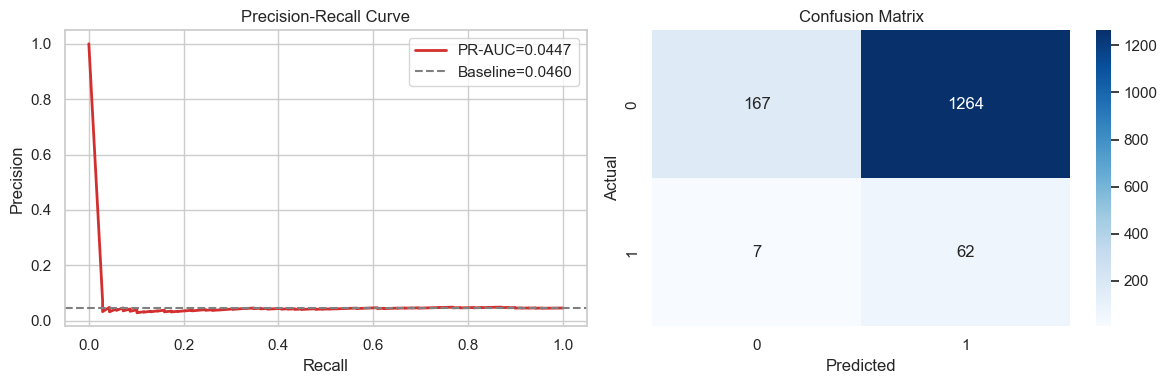

Calibration comparison (test):


,version,thr,pr_auc,f2,business_loss
0,raw,0.20,0.044732,0.193508,982000.0
1,isotonic,0.05,0.049324,0.194257,715500.0
2,sigmoid,0.06,0.054398,0.194257,715500.0


McNemar exact test between 'Autoencoder (Anomaly)' and 'Logistic Regression': b=89, c=972, p-value=0.000000


In [22]:
# Best model diagnostics + calibration + McNemar
best_name = results_df.iloc[0]["Model"]
best_info = pred_store[best_name]
best_thr = float(best_info["threshold"])
proba_test = best_info["test_proba"]
pred_test = best_info["test_pred"]

print(f"Best model: {best_name}")
print(f"Selected threshold (F2 + business-loss objective): {best_thr:.4f}")
print(f"Business loss (test): {business_loss(y_test, pred_test, fn_cost=50000, fp_cost=500):,.0f}")
print(classification_report(y_test, pred_test, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
p, r, _ = precision_recall_curve(y_test, proba_test)
axes[0].plot(r, p, color="#d32f2f", lw=2, label=f"PR-AUC={average_precision_score(y_test, proba_test):.4f}")
axes[0].axhline(y_test.mean(), ls="--", color="gray", label=f"Baseline={y_test.mean():.4f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()

cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

if isinstance(best_info["bundle"], Pipeline):
    base_pipe = clone(best_info["bundle"])
    cal_iso = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=TimeSeriesSplit(n_splits=5))
    cal_sig = CalibratedClassifierCV(estimator=clone(base_pipe), method="sigmoid", cv=TimeSeriesSplit(n_splits=5))
    cal_iso.fit(X_train, y_train)
    cal_sig.fit(X_train, y_train)

    iso_val = cal_iso.predict_proba(X_val)[:, 1]
    sig_val = cal_sig.predict_proba(X_val)[:, 1]
    iso_thr, _ = tune_threshold_bundle(y_val, iso_val, beta=2.0, fn_cost=50000, fp_cost=500)
    sig_thr, _ = tune_threshold_bundle(y_val, sig_val, beta=2.0, fn_cost=50000, fp_cost=500)

    iso_proba = cal_iso.predict_proba(X_test)[:, 1]
    sig_proba = cal_sig.predict_proba(X_test)[:, 1]
    iso_pred = (iso_proba >= iso_thr).astype(int)
    sig_pred = (sig_proba >= sig_thr).astype(int)

    print("Calibration comparison (test):")
    display(pd.DataFrame([
        {
            "version": "raw",
            "thr": best_thr,
            "pr_auc": average_precision_score(y_test, proba_test),
            "f2": fbeta_score(y_test, pred_test, beta=2.0, zero_division=0),
            "business_loss": business_loss(y_test, pred_test, fn_cost=50000, fp_cost=500),
        },
        {
            "version": "isotonic",
            "thr": iso_thr,
            "pr_auc": average_precision_score(y_test, iso_proba),
            "f2": fbeta_score(y_test, iso_pred, beta=2.0, zero_division=0),
            "business_loss": business_loss(y_test, iso_pred, fn_cost=50000, fp_cost=500),
        },
        {
            "version": "sigmoid",
            "thr": sig_thr,
            "pr_auc": average_precision_score(y_test, sig_proba),
            "f2": fbeta_score(y_test, sig_pred, beta=2.0, zero_division=0),
            "business_loss": business_loss(y_test, sig_pred, fn_cost=50000, fp_cost=500),
        },
    ]))

if len(results_df) >= 2 and binomtest is not None:
    m1, m2 = results_df.loc[0, "Model"], results_df.loc[1, "Model"]
    p1 = pred_store[m1]["test_pred"]
    p2 = pred_store[m2]["test_pred"]
    y_true = y_test.values
    b = int(np.sum((p1 == y_true) & (p2 != y_true)))
    c = int(np.sum((p1 != y_true) & (p2 == y_true)))
    if b + c > 0:
        p_value = binomtest(min(b, c), n=b + c, p=0.5, alternative="two-sided").pvalue
        print(f"McNemar exact test between '{m1}' and '{m2}': b={b}, c={c}, p-value={p_value:.6f}")
    else:
        print("McNemar test: no discordant pairs between top-2 models.")


## 5) Regression (Severity) + Risk Triage


In [23]:
# Regression split + training (RidgeCV + RandomForestRegressor)
df_reg = df[df["CLAIM_AMOUNT"].notna()].copy()
df_reg["TXN_DATE_TIME"] = pd.to_datetime(df_reg["TXN_DATE_TIME"], errors="coerce")
df_reg = df_reg.sort_values("TXN_DATE_TIME").reset_index(drop=True)
df_reg = add_domain_features(df_reg)

n_reg = len(df_reg)
tr_end = int(n_reg * 0.70)
va_end = int(n_reg * 0.85)
reg_train = df_reg.iloc[:tr_end].copy()
reg_val = df_reg.iloc[tr_end:va_end].copy()
reg_test = df_reg.iloc[va_end:].copy()

drop_reg = [
    "CLAIM_AMOUNT", "CLAIM_STATUS", "TXN_DATE_TIME",
    "CUSTOMER_NAME", "SSN", "ACCT_NUMBER", "ROUTING_NUMBER",
    "EMP_ACCT_NUMBER", "EMP_ROUTING_NUMBER", "ADDRESS_LINE1",
    "TRANSACTION_ID", "POLICY_NUMBER",
]

Xr_train_raw = reg_train.drop(columns=[c for c in drop_reg if c in reg_train.columns], errors="ignore")
Xr_val_raw = reg_val.drop(columns=[c for c in drop_reg if c in reg_val.columns], errors="ignore")
Xr_test_raw = reg_test.drop(columns=[c for c in drop_reg if c in reg_test.columns], errors="ignore")

yr_train = np.log1p(reg_train["CLAIM_AMOUNT"])
yr_test_log = np.log1p(reg_test["CLAIM_AMOUNT"])
yr_test = reg_test["CLAIM_AMOUNT"].values

Xr_train, Xr_val, Xr_test, _ = cap_high_cardinality(Xr_train_raw, Xr_val_raw, Xr_test_raw, max_unique=50)
num_r = list(Xr_train.select_dtypes(include=[np.number]).columns)
cap_r = fit_iqr_caps(Xr_train, num_r, mult=3.0)
Xr_train = apply_iqr_caps(Xr_train, cap_r)
Xr_val = apply_iqr_caps(Xr_val, cap_r)
Xr_test = apply_iqr_caps(Xr_test, cap_r)

# Convert datetime columns to numeric timestamps for sklearn compatibility
Xr_train = normalize_datetime_cols(Xr_train)
Xr_val = normalize_datetime_cols(Xr_val)
Xr_test = normalize_datetime_cols(Xr_test)

ridge_pipe = Pipeline([("prep", build_preprocessor(Xr_train)), ("model", RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100]))])
ridge_pipe.fit(Xr_train, yr_train)

rf_reg_pipe = Pipeline([("prep", build_preprocessor(Xr_train)), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))])
rf_reg_param = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_leaf": [1, 2, 5, 10],
}
REG_TUNE_ROWS = min(4000, len(Xr_train))
REG_SEARCH_ITERS = 8
REG_CV_SPLITS = 2

if REG_TUNE_ROWS < len(Xr_train):
    tune_idx = np.random.RandomState(42).choice(len(Xr_train), size=REG_TUNE_ROWS, replace=False)
    Xr_tune = Xr_train.iloc[tune_idx]
    yr_tune = yr_train.iloc[tune_idx]
else:
    Xr_tune = Xr_train
    yr_tune = yr_train

rf_reg_search = RandomizedSearchCV(
    rf_reg_pipe, rf_reg_param, n_iter=REG_SEARCH_ITERS, cv=TimeSeriesSplit(n_splits=REG_CV_SPLITS),
    scoring="neg_mean_absolute_error", n_jobs=1, random_state=42, verbose=1
)
rf_reg_search.fit(Xr_tune, yr_tune)

best_rf_reg = clone(rf_reg_search.best_estimator_)
best_rf_reg.fit(Xr_train, yr_train)

reg_models = {"RidgeCV": ridge_pipe, "RandomForestRegressor": best_rf_reg}
reg_rows = []
for name, model in reg_models.items():
    pred_log = model.predict(Xr_test)
    pred = np.expm1(pred_log)
    reg_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(yr_test, pred),
        "RMSE": np.sqrt(mean_squared_error(yr_test, pred)),
        "R2_log": r2_score(yr_test_log, pred_log),
    })

reg_results = pd.DataFrame(reg_rows).sort_values("RMSE").reset_index(drop=True)
display(reg_results)
best_reg_name = reg_results.iloc[0]["Model"]
best_regressor = reg_models[best_reg_name]
print("Best regressor:", best_reg_name)


Fitting 2 folds for each of 8 candidates, totalling 16 fits


,Model,MAE,RMSE,R2_log
0,RandomForestRegressor,1334.084998,4639.647232,0.998380
1,RidgeCV,4573.005744,9091.278684,0.922421


Best regressor: RandomForestRegressor


Top-10% investigation fraud hit rate: 0.0733
Baseline fraud rate: 0.0460
Lift: 1.59x


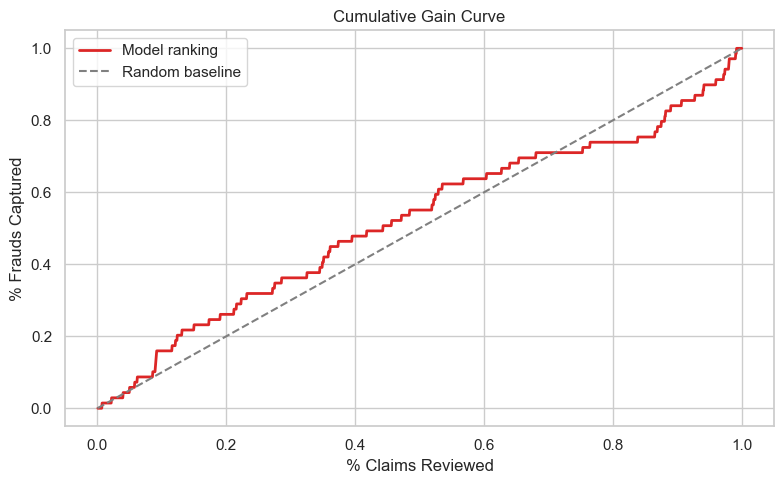

,fraud_probability,predicted_claim_amount,risk_score,actual_fraud,cum_claims_pct,cum_frauds,cum_frauds_pct
0,1.000000,80155.701174,80155.701174,0,0.000667,0,0.000000
1,1.000000,79955.596375,79955.596375,0,0.001333,0,0.000000
2,0.949046,79609.868603,75553.466302,0,0.002000,0,0.000000
3,0.900658,73789.923693,66459.510291,0,0.002667,0,0.000000
4,1.000000,65945.917004,65945.917004,0,0.003333,0,0.000000
5,0.872071,70933.557897,61859.132299,0,0.004000,0,0.000000
6,0.797945,74902.305990,59767.930990,0,0.004667,0,0.000000
7,0.773225,77122.783636,59633.294139,0,0.005333,0,0.000000
8,0.922381,64097.511643,59122.316221,0,0.006000,0,0.000000
9,0.835397,70317.611263,58743.104552,0,0.006667,0,0.000000


In [24]:
# Risk triage + cumulative gain / lift curve
severity_pred = np.expm1(best_regressor.predict(Xr_test))
n_common = min(len(proba_test), len(severity_pred), len(y_test))
risk = proba_test[:n_common] * severity_pred[:n_common]
actual = y_test.values[:n_common]

risk_df = pd.DataFrame({
    "fraud_probability": proba_test[:n_common],
    "predicted_claim_amount": severity_pred[:n_common],
    "risk_score": risk,
    "actual_fraud": actual,
}).sort_values("risk_score", ascending=False).reset_index(drop=True)

k = max(1, int(0.10 * len(risk_df)))
top_hit = risk_df.head(k)["actual_fraud"].mean()
baseline = risk_df["actual_fraud"].mean()
lift = top_hit / baseline if baseline > 0 else np.nan

print(f"Top-10% investigation fraud hit rate: {top_hit:.4f}")
print(f"Baseline fraud rate: {baseline:.4f}")
print(f"Lift: {lift:.2f}x")

risk_df["cum_claims_pct"] = (np.arange(len(risk_df)) + 1) / len(risk_df)
risk_df["cum_frauds"] = risk_df["actual_fraud"].cumsum()
total_frauds = max(1, risk_df["actual_fraud"].sum())
risk_df["cum_frauds_pct"] = risk_df["cum_frauds"] / total_frauds

plt.figure(figsize=(8, 5))
plt.plot(risk_df["cum_claims_pct"], risk_df["cum_frauds_pct"], label="Model ranking", color="#dc2626", lw=2)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random baseline")
plt.xlabel("% Claims Reviewed")
plt.ylabel("% Frauds Captured")
plt.title("Cumulative Gain Curve")
plt.legend()
plt.tight_layout()
plt.show()

risk_df.head(20)


## 6) Explainability + Artifact Saving


In [25]:
# SHAP summary for best tree-like classifier
best_bundle = pred_store[best_name]["bundle"]

def get_tree_estimator(bundle):
    if isinstance(bundle, Pipeline):
        return bundle.named_steps.get("model"), bundle.named_steps.get("prep")
    return bundle.get("model"), bundle.get("prep")

model_obj, prep_obj = get_tree_estimator(best_bundle)
is_tree_model = model_obj.__class__.__name__ in {
    "RandomForestClassifier", "GradientBoostingClassifier", "XGBClassifier", "LGBMClassifier", "DecisionTreeClassifier"
}

if shap is not None and is_tree_model and prep_obj is not None:
    X_sample = X_test.sample(min(200, len(X_test)), random_state=42)
    X_trans = prep_obj.transform(X_sample)
    if hasattr(X_trans, "toarray"):
        X_trans = X_trans.toarray()

    explainer = shap.TreeExplainer(model_obj)
    shap_values = explainer.shap_values(X_trans)
    sv = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else shap_values

    feature_names = None
    try:
        feature_names = prep_obj.get_feature_names_out()
    except Exception:
        feature_names = None
    shap.summary_plot(sv, X_trans, feature_names=feature_names, max_display=15)
else:
    print("SHAP skipped (missing package or best model not tree-based with accessible preprocessor).")


SHAP skipped (missing package or best model not tree-based with accessible preprocessor).


Inspection model for permutation/PDP: Logistic Regression
Top permutation importances:


,feature,importance_mean,importance_std
24,INCIDENT_STATE,0.011157,0.000993
61,vendor_rolling_fraud_rate,0.007626,0.003529
9,STATE,0.004021,0.000945
19,CUSTOMER_EDUCATION_LEVEL,0.002851,0.000428
48,VENDOR_ID_MISSING,0.002561,0.001575
25,INCIDENT_CITY,0.002109,0.004834
34,STATE_AGENT,0.002093,0.000740
69,agent_claim_volume,0.001765,0.000212
17,HOUSE_TYPE,0.001756,0.001141
40,STATE_VENDOR,0.001563,0.001219


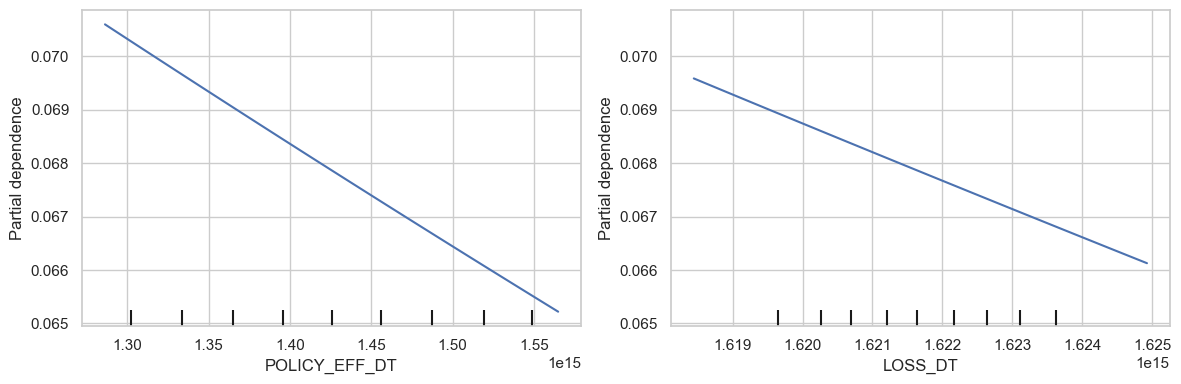

In [26]:
# Permutation Importance + PDP (Partial Dependence Plot)
inspect_name = None
inspect_bundle = None
for nm, info in pred_store.items():
    b = info["bundle"]
    if isinstance(b, Pipeline):
        inspect_name = nm
        inspect_bundle = b
        break

if inspect_bundle is None:
    print("No sklearn Pipeline model available for permutation/PDP inspection.")
else:
    print(f"Inspection model for permutation/PDP: {inspect_name}")
    perm = permutation_importance(
        inspect_bundle,
        X_test,
        y_test,
        n_repeats=2,
        random_state=42,
        scoring="average_precision",
        n_jobs=-1,
    )
    perm_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    print("Top permutation importances:")
    display(perm_df.head(20))

    pdp_features = [c for c in X_test.select_dtypes(include=[np.number]).columns if X_test[c].nunique(dropna=True) > 5][:2]
    if len(pdp_features) > 0:
        fig, ax = plt.subplots(1, len(pdp_features), figsize=(6 * len(pdp_features), 4))
        if len(pdp_features) == 1:
            ax = [ax]
        PartialDependenceDisplay.from_estimator(inspect_bundle, X_test, features=pdp_features, ax=ax)
        plt.tight_layout()
        plt.show()
    else:
        print("No suitable numeric features found for PDP.")


In [27]:
# Save model artifacts + thresholds + reports
artifacts_dir = Path("models")
reports_dir = Path("reports")
artifacts_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

best_classifier = pred_store[best_name]["bundle"]
best_threshold = float(pred_store[best_name]["threshold"])

joblib.dump(best_classifier, artifacts_dir / "best_classifier.pkl")
joblib.dump(best_regressor, artifacts_dir / "best_regressor.pkl")

threshold_payload = {
    "best_classifier": best_name,
    "threshold": best_threshold,
    "selected_on": "validation_set_f2",
}
(reports_dir / "best_classifier_threshold.json").write_text(json.dumps(threshold_payload, indent=2), encoding="utf-8")

results_df.to_csv(reports_dir / "classification_holdout_metrics.csv", index=False)
cv_summary.to_csv(reports_dir / "classification_cv_metrics.csv", index=False)
reg_results.to_csv(reports_dir / "regression_metrics.csv", index=False)
risk_df.to_csv(reports_dir / "risk_ranking_top.csv", index=False)

print("Saved artifacts:")
print("- models/best_classifier.pkl")
print("- models/best_regressor.pkl")
print("- reports/best_classifier_threshold.json")
print("- reports/classification_holdout_metrics.csv")
print("- reports/classification_cv_metrics.csv")
print("- reports/regression_metrics.csv")
print("- reports/risk_ranking_top.csv")


Saved artifacts:
- models/best_classifier.pkl
- models/best_regressor.pkl
- reports/best_classifier_threshold.json
- reports/classification_holdout_metrics.csv
- reports/classification_cv_metrics.csv
- reports/regression_metrics.csv
- reports/risk_ranking_top.csv


In [28]:
# Production-readiness checks: schema, drift, versioning, config
print("Production readiness snapshot:")
print(f"- Pandera available: {pa is not None}")
print(f"- Evidently available: {evidently is not None}")
print(f"- MLflow available: {mlflow is not None}")
print(f"- Optuna available: {optuna is not None}")

configs_dir = Path("configs")
configs_dir.mkdir(parents=True, exist_ok=True)
config_text = """split:
  train: 0.70
  val: 0.15
  test: 0.15
models:
  rf_search_iter: 15
  xgb_search_iter: 20
  cv_splits: 5
  use_optuna_if_available: true
threshold:
  objective: f2_with_business_loss_tiebreak
  scan_range: [0.05, 0.50]
  step: 0.01
business_cost:
  false_negative: 50000
  false_positive: 500
"""
(configs_dir / "pipeline_config.yaml").write_text(config_text, encoding="utf-8")
print("- Saved config: configs/pipeline_config.yaml")

if pa is not None:
    print("- Pandera installed: you can add strict column-level schema assertions in deployment.")
else:
    print("- Pandera not installed: run `pip install pandera` for schema validation.")

if evidently is not None:
    print("- Evidently installed: add fraud-rate, feature-drift, prediction-drift dashboards in monitoring.")
else:
    print("- Evidently not installed: run `pip install evidently` for drift monitoring.")

if mlflow is not None:
    print("- MLflow installed: log params/metrics/artifacts for experiment versioning.")
else:
    print("- MLflow not installed: run `pip install mlflow` for experiment tracking.")


Production readiness snapshot:
- Pandera available: False
- Evidently available: False
- MLflow available: False
- Optuna available: False
- Saved config: configs/pipeline_config.yaml
- Pandera not installed: run `pip install pandera` for schema validation.
- Evidently not installed: run `pip install evidently` for drift monitoring.
- MLflow not installed: run `pip install mlflow` for experiment tracking.


In [29]:
# Final quick summary
print("\nPipeline summary")
print("- EDA section added: imbalance, distributions, missingness, category fraud rates, temporal trend")
print("- Extra EDA added: fraud vs claim/premium, top fraudulent agents/vendors, state heatmap, pairplot")
print("- New behavioral fraud signals: customer/agent/vendor rolling windows, days_since_last_claim, rolling_fraud_rate, claim_velocity")
print("- Robust preprocessing: RobustScaler + IQR capping + missing indicators + high-cardinality handling")
print("- Signal diagnostics: correlation, Cramer's V, mutual information, VIF")
print("- Models: hold-out metrics + 5-fold TimeSeries CV + CatBoost + Isolation Forest + Autoencoder anomaly detectors + business-loss metric")
print("- Thresholding: optimized over 0.05-0.50 using F2 with business-loss tiebreak")
print("- Tuning: expanded XGBoost search space (gamma, reg_alpha, reg_lambda) + Optuna when available")
print("- Explainability: SHAP + permutation importance + PDP")
print("- Deployment assets: saved models, threshold JSON, reports, YAML config")



Pipeline summary
- EDA section added: imbalance, distributions, missingness, category fraud rates, temporal trend
- Extra EDA added: fraud vs claim/premium, top fraudulent agents/vendors, state heatmap, pairplot
- New behavioral fraud signals: customer/agent/vendor rolling windows, days_since_last_claim, rolling_fraud_rate, claim_velocity
- Robust preprocessing: RobustScaler + IQR capping + missing indicators + high-cardinality handling
- Signal diagnostics: correlation, Cramer's V, mutual information, VIF
- Models: hold-out metrics + 5-fold TimeSeries CV + CatBoost + Isolation Forest + Autoencoder anomaly detectors + business-loss metric
- Thresholding: optimized over 0.05-0.50 using F2 with business-loss tiebreak
- Tuning: expanded XGBoost search space (gamma, reg_alpha, reg_lambda) + Optuna when available
- Explainability: SHAP + permutation importance + PDP
- Deployment assets: saved models, threshold JSON, reports, YAML config
